# Data Cleaning Analysis & Visualization

## Results & Analysis for Comprehensive Report

This notebook provides comprehensive analysis and visualization for the **Results & Analysis** section of the comprehensive report. It includes:

0. **Input Data Analysis**: Analysis of raw input data and comparison with cleaned data
1. **Data Quality Metrics**: Completeness, accuracy, and consistency analysis
2. **Quantitative Results**: Professional-quality figures and tables
3. **Performance Metrics**: RMSE, MAPE, R², and cross-source validation
4. **Computational Efficiency**: Runtime comparisons, memory usage, scalability analysis

---

## Table of Contents

0. [Input Data Analysis & Cleaning Impact Assessment](#input)
1. [Setup and Configuration](#setup)
2. [Data Quality Metrics](#quality)
3. [Speed Distribution Analysis](#speed)
4. [Performance Metrics & Cross-Source Validation](#performance)
4. [Computational Efficiency Analysis](#efficiency)
5. [Summary and Conclusions](#summary)

In [100]:
# Imports
import sys
import os
import json
import time
from pathlib import Path
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Optional imports with fallback
try:
    import psutil
    HAS_PSUTIL = True
except ImportError:
    HAS_PSUTIL = False
    print("⚠️  psutil not available - memory tracking disabled")

try:
    from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("⚠️  sklearn not available - using manual implementations")
    # Manual implementations
    def mean_squared_error(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)
    
    def mean_absolute_percentage_error(y_true, y_pred):
        return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    def r2_score(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ss_res / (ss_tot + 1e-10))

# Set style for professional figures
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Set up paths
PROJECT_ROOT = Path.cwd().parent
OUTPUT_PATH = PROJECT_ROOT / "data" / "output"
CLEANED_DATA_PATH = OUTPUT_PATH / "cleaned_data"
INPUT_DATA_PATH = PROJECT_ROOT / "data_cleaning_fusion_datasets"
DATABASE_PATH = OUTPUT_PATH / "database" / "unified_database.db"
FIGURES_PATH = OUTPUT_PATH / "figures"
METRICS_PATH = OUTPUT_PATH / "quality_metrics"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH.mkdir(parents=True, exist_ok=True)

# Cleaned data file paths
WAYPOINT_CLEANED = CLEANED_DATA_PATH / "waypoint_cleaned.csv"
WAYPOINT_CLEANED_MATCHED = CLEANED_DATA_PATH / "waypoint_cleaned_mapmatched.csv"
TRAJS_CLEANED = CLEANED_DATA_PATH / "trajs_cleaned.csv"
MAP_MATCHING_CLEANED = CLEANED_DATA_PATH / "map_matching_cleaned.csv"

# Input (raw) data file paths
WAYPOINT_RAW = INPUT_DATA_PATH / "waypoint" / "waypoint.csv"
TRAJS_RAW = INPUT_DATA_PATH / "trip path" / "trajs.csv"
TRAJS_HEADERS = INPUT_DATA_PATH / "trip path" / "TripBulkReportTrajectoriesHeaders.csv"

# Verify cleaned data files exist
print("="*80)
print("DATA CLEANING ANALYSIS & VISUALIZATION")
print("="*80)
print("📂 Checking cleaned data files...")
if WAYPOINT_CLEANED.exists():
    print(f"   ✅ Waypoint cleaned data: {WAYPOINT_CLEANED}")
else:
    print(f"   ⚠️  Waypoint cleaned data not found: {WAYPOINT_CLEANED}")
if TRAJS_CLEANED.exists():
    print(f"   ✅ Trip path cleaned data: {TRAJS_CLEANED}")
else:
    print(f"   ⚠️  Trip path cleaned data not found: {TRAJS_CLEANED}")
if MAP_MATCHING_CLEANED.exists():
    print(f"   ✅ Map matching cleaned data: {MAP_MATCHING_CLEANED}")
else:
    print(f"   ⚠️  Map matching cleaned data not found: {MAP_MATCHING_CLEANED}")
if WAYPOINT_CLEANED_MATCHED.exists():
    print(f"   ✅ Waypoint map-matched data: {WAYPOINT_CLEANED_MATCHED}")
else:
    print(f"   ⚠️  Waypoint map-matched data not found: {WAYPOINT_CLEANED_MATCHED}")

print(f"\n✅ Setup complete!")
print(f"Figures will be saved to: {FIGURES_PATH}")
print(f"Metrics will be saved to: {METRICS_PATH}")

⚠️  sklearn not available - using manual implementations
DATA CLEANING ANALYSIS & VISUALIZATION
📂 Checking cleaned data files...
   ✅ Waypoint cleaned data: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modelling and Applications/Project/data/output/cleaned_data/waypoint_cleaned.csv
   ✅ Trip path cleaned data: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modelling and Applications/Project/data/output/cleaned_data/trajs_cleaned.csv
   ✅ Map matching cleaned data: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modelling and Applications/Project/data/output/cleaned_data/map_matching_cleaned.csv
   ✅ Waypoint map-matched data: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modelling and Applications/Project/data/output/cleaned_data/waypoint_cleaned_mapmatched.csv

✅ Setup complete!
Figures will be saved to: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modelling and Applications/Project

---

## 0. Input Data Analysis & Cleaning Impact Assessment {#input}

### Purpose
This section provides comprehensive analysis of the **raw input data** and compares it with the **final cleaned data** to:
- Understand the initial data characteristics and quality
- Quantify the impact of each cleaning step
- Visualize data removal percentages
- Assess data quality improvements

### Key Metrics
- **Input Data Statistics**: Record counts, file sizes, data ranges
- **Cleaning Impact**: Records removed at each step, percentage retention
- **Data Quality Comparison**: Before vs. after cleaning metrics
- **Visualizations**: Comparison charts, quality improvements


In [101]:
# Input Data Analysis: Load and analyze raw input files
print("="*80)
print("INPUT DATA ANALYSIS")
print("="*80)

input_stats = {}

# Analyze waypoint input data
if WAYPOINT_RAW.exists():
    print("\n📊 Analyzing waypoint input data...")
    print(f"   File: {WAYPOINT_RAW}")
    file_size = WAYPOINT_RAW.stat().st_size / (1024**3)  # GB
    print(f"   File size: {file_size:.2f} GB")
    
    # Count rows (efficient method for large files)
    print("   Counting records...")
    row_count = sum(1 for _ in open(WAYPOINT_RAW)) - 1  # Subtract header
    print(f"   Total records: {row_count:,}")
    
    # Load sample for column analysis
    print("   Loading sample for column analysis...")
    waypoint_sample = pd.read_csv(WAYPOINT_RAW, nrows=10000, low_memory=False)
    
    input_stats['waypoint'] = {
        'file_size_gb': file_size,
        'total_records': row_count,
        'columns': list(waypoint_sample.columns),
        'sample_data': waypoint_sample
    }
    
    # Check for key columns
    if 'speed_mph' in waypoint_sample.columns:
        speed_sample = pd.read_csv(WAYPOINT_RAW, usecols=['speed_mph'], nrows=100000, low_memory=False)
        speed_sample = pd.to_numeric(speed_sample['speed_mph'], errors='coerce')
        input_stats['waypoint']['speed_stats'] = {
            'mean': speed_sample.mean(),
            'median': speed_sample.median(),
            'std': speed_sample.std(),
            'min': speed_sample.min(),
            'max': speed_sample.max(),
            'null_count': speed_sample.isna().sum()
        }
    
    print(f"   ✅ Analyzed {row_count:,} waypoint records")
else:
    print(f"   ⚠️  Waypoint input file not found: {WAYPOINT_RAW}")

# Analyze trip path input data
if TRAJS_RAW.exists():
    print("\n📊 Analyzing trip path input data...")
    print(f"   File: {TRAJS_RAW}")
    file_size = TRAJS_RAW.stat().st_size / (1024**3)  # GB
    print(f"   File size: {file_size:.2f} GB")
    
    # Count rows
    print("   Counting records...")
    row_count = sum(1 for _ in open(TRAJS_RAW)) - 1  # Subtract header
    print(f"   Total records: {row_count:,}")
    
    # Load headers if available
    if TRAJS_HEADERS.exists():
        headers_df = pd.read_csv(TRAJS_HEADERS)
        column_names = headers_df.iloc[0].tolist() if len(headers_df) > 0 else None
    else:
        column_names = None
    
    # Load sample for analysis
    print("   Loading sample for column analysis...")
    trajs_sample = pd.read_csv(TRAJS_RAW, nrows=10000, low_memory=False, header=None)
    if column_names and len(column_names) == len(trajs_sample.columns):
        trajs_sample.columns = column_names[:len(trajs_sample.columns)]
    
    input_stats['trajs'] = {
        'file_size_gb': file_size,
        'total_records': row_count,
        'columns': list(trajs_sample.columns) if column_names else [f'col_{i}' for i in range(len(trajs_sample.columns))],
        'sample_data': trajs_sample
    }
    
    # Check for speed column (CrossingSpeedKph is column 15, index 14)
    if len(trajs_sample.columns) > 14:
        speed_col = trajs_sample.columns[14] if column_names else 'col_14'
        try:
            speed_sample = pd.read_csv(TRAJS_RAW, usecols=[14], nrows=100000, low_memory=False, header=None)
            speed_sample.columns = [speed_col]
            speed_sample[speed_col] = pd.to_numeric(speed_sample[speed_col], errors='coerce')
            input_stats['trajs']['speed_stats'] = {
                'mean': speed_sample[speed_col].mean(),
                'median': speed_sample[speed_col].median(),
                'std': speed_sample[speed_col].std(),
                'min': speed_sample[speed_col].min(),
                'max': speed_sample[speed_col].max(),
                'null_count': speed_sample[speed_col].isna().sum()
            }
        except:
            pass
    
    print(f"   ✅ Analyzed {row_count:,} trip path records")
else:
    print(f"   ⚠️  Trip path input file not found: {TRAJS_RAW}")

print("\n" + "="*80)
print("INPUT DATA SUMMARY")
print("="*80)
for source, stats in input_stats.items():
    print(f"\n{source.upper()}:")
    print(f"  Total Records: {stats['total_records']:,}")
    print(f"  File Size: {stats['file_size_gb']:.2f} GB")
    print(f"  Columns: {len(stats['columns'])}")
    if 'speed_stats' in stats:
        print(f"  Speed (sample): Mean={stats['speed_stats']['mean']:.2f}, "
              f"Median={stats['speed_stats']['median']:.2f}, "
              f"Std={stats['speed_stats']['std']:.2f}")


INPUT DATA ANALYSIS

📊 Analyzing waypoint input data...
   File: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modelling and Applications/Project/data_cleaning_fusion_datasets/waypoint/waypoint.csv
   File size: 1.40 GB
   Counting records...
   Total records: 19,471,725
   Loading sample for column analysis...
   ✅ Analyzed 19,471,725 waypoint records

📊 Analyzing trip path input data...
   File: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modelling and Applications/Project/data_cleaning_fusion_datasets/trip path/trajs.csv
   File size: 1.90 GB
   Counting records...
   Total records: 8,356,493
   Loading sample for column analysis...
   ✅ Analyzed 8,356,493 trip path records

INPUT DATA SUMMARY

WAYPOINT:
  Total Records: 19,471,725
  File Size: 1.40 GB
  Columns: 9
  Speed (sample): Mean=37.45, Median=41.00, Std=30.36

TRAJS:
  Total Records: 8,356,493
  File Size: 1.90 GB
  Columns: 17
  Speed (sample): Mean=118.21, Median=86.92, Std=670.

### 0.1 Data Removal Analysis by Cleaning Step

This section quantifies the impact of each cleaning step on the dataset.


In [102]:
# Compare input data with cleaned data and calculate removal percentages
print("\n" + "="*80)
print("DATA REMOVAL ANALYSIS: INPUT vs CLEANED")
print("="*80)

cleaning_impact = {}

# Compare waypoint data (Input → Cleaned → Map-Matched)
if WAYPOINT_RAW.exists() and WAYPOINT_CLEANED.exists():
    print("\n📊 Waypoint Data Comparison:")
    input_count = input_stats['waypoint']['total_records']
    
    # Count cleaned records
    cleaned_count = sum(1 for _ in open(WAYPOINT_CLEANED)) - 1
    removed = input_count - cleaned_count
    removal_pct = (removed / input_count * 100) if input_count > 0 else 0
    retention_pct = (cleaned_count / input_count * 100) if input_count > 0 else 0
    
    # Check map-matched data if available
    matched_count = None
    if WAYPOINT_CLEANED_MATCHED.exists():
        matched_count = sum(1 for _ in open(WAYPOINT_CLEANED_MATCHED)) - 1
        matched_removed = cleaned_count - matched_count
        matched_removal_pct = (matched_removed / cleaned_count * 100) if cleaned_count > 0 else 0
        matched_retention_pct = (matched_count / cleaned_count * 100) if cleaned_count > 0 else 0
        final_retention_pct = (matched_count / input_count * 100) if input_count > 0 else 0
    
    cleaning_impact['waypoint'] = {
        'input_records': input_count,
        'cleaned_records': cleaned_count,
        'removed_records': removed,
        'removal_percentage': removal_pct,
        'retention_percentage': retention_pct
    }
    
    if matched_count is not None:
        cleaning_impact['waypoint']['matched_records'] = matched_count
        cleaning_impact['waypoint']['matched_removal_pct'] = matched_removal_pct
        cleaning_impact['waypoint']['matched_retention_pct'] = matched_retention_pct
        cleaning_impact['waypoint']['final_retention_pct'] = final_retention_pct
    
    print(f"   Input records: {input_count:,}")
    print(f"   Cleaned records: {cleaned_count:,}")
    print(f"   Removed (cleaning): {removed:,} ({removal_pct:.2f}%)")
    print(f"   Retention (cleaning): {retention_pct:.2f}%")
    if matched_count is not None:
        print(f"   Map-matched records: {matched_count:,}")
        print(f"   Removed by map matching: {cleaned_count - matched_count:,} ({matched_removal_pct:.2f}% of cleaned)")
        print(f"   Final retention (from input): {final_retention_pct:.2f}%")

# Compare trip path data
if TRAJS_RAW.exists() and TRAJS_CLEANED.exists():
    print("\n📊 Trip Path Data Comparison:")
    input_count = input_stats['trajs']['total_records']
    
    # Count cleaned records
    cleaned_count = sum(1 for _ in open(TRAJS_CLEANED)) - 1
    removed = input_count - cleaned_count
    removal_pct = (removed / input_count * 100) if input_count > 0 else 0
    retention_pct = (cleaned_count / input_count * 100) if input_count > 0 else 0
    
    cleaning_impact['trajs'] = {
        'input_records': input_count,
        'cleaned_records': cleaned_count,
        'removed_records': removed,
        'removal_percentage': removal_pct,
        'retention_percentage': retention_pct
    }
    
    print(f"   Input records: {input_count:,}")
    print(f"   Cleaned records: {cleaned_count:,}")
    print(f"   Removed records: {removed:,} ({removal_pct:.2f}%)")
    print(f"   Retention rate: {retention_pct:.2f}%")

# Create summary DataFrame
if cleaning_impact:
    impact_df = pd.DataFrame([
        {
            'Data Source': source,
            'Input Records': stats['input_records'],
            'Cleaned Records': stats['cleaned_records'],
            'Removed Records': stats['removed_records'],
            'Removal %': f"{stats['removal_percentage']:.2f}%",
            'Retention %': f"{stats['retention_percentage']:.2f}%"
        }
        for source, stats in cleaning_impact.items()
    ])
    
    print("\n" + "="*80)
    print("CLEANING IMPACT SUMMARY")
    print("="*80)
    print(impact_df.to_string(index=False))
    
    # Save to CSV
    impact_df.to_csv(METRICS_PATH / "cleaning_impact_summary.csv", index=False)
    print(f"\n✅ Saved: cleaning_impact_summary.csv")



DATA REMOVAL ANALYSIS: INPUT vs CLEANED

📊 Waypoint Data Comparison:
   Input records: 19,471,725
   Cleaned records: 12,520,301
   Removed (cleaning): 6,951,424 (35.70%)
   Retention (cleaning): 64.30%
   Map-matched records: 6,288,904
   Removed by map matching: 6,231,397 (49.77% of cleaned)
   Final retention (from input): 32.30%

📊 Trip Path Data Comparison:
   Input records: 8,356,493
   Cleaned records: 377,563
   Removed records: 7,978,930 (95.48%)
   Retention rate: 4.52%

CLEANING IMPACT SUMMARY
Data Source  Input Records  Cleaned Records  Removed Records Removal % Retention %
   waypoint       19471725         12520301          6951424    35.70%      64.30%
      trajs        8356493           377563          7978930    95.48%       4.52%

✅ Saved: cleaning_impact_summary.csv


### 0.2 Input vs Cleaned Data Visualizations

Visual comparison of input and cleaned datasets.



✅ Saved: input_vs_cleaned_comparison.png


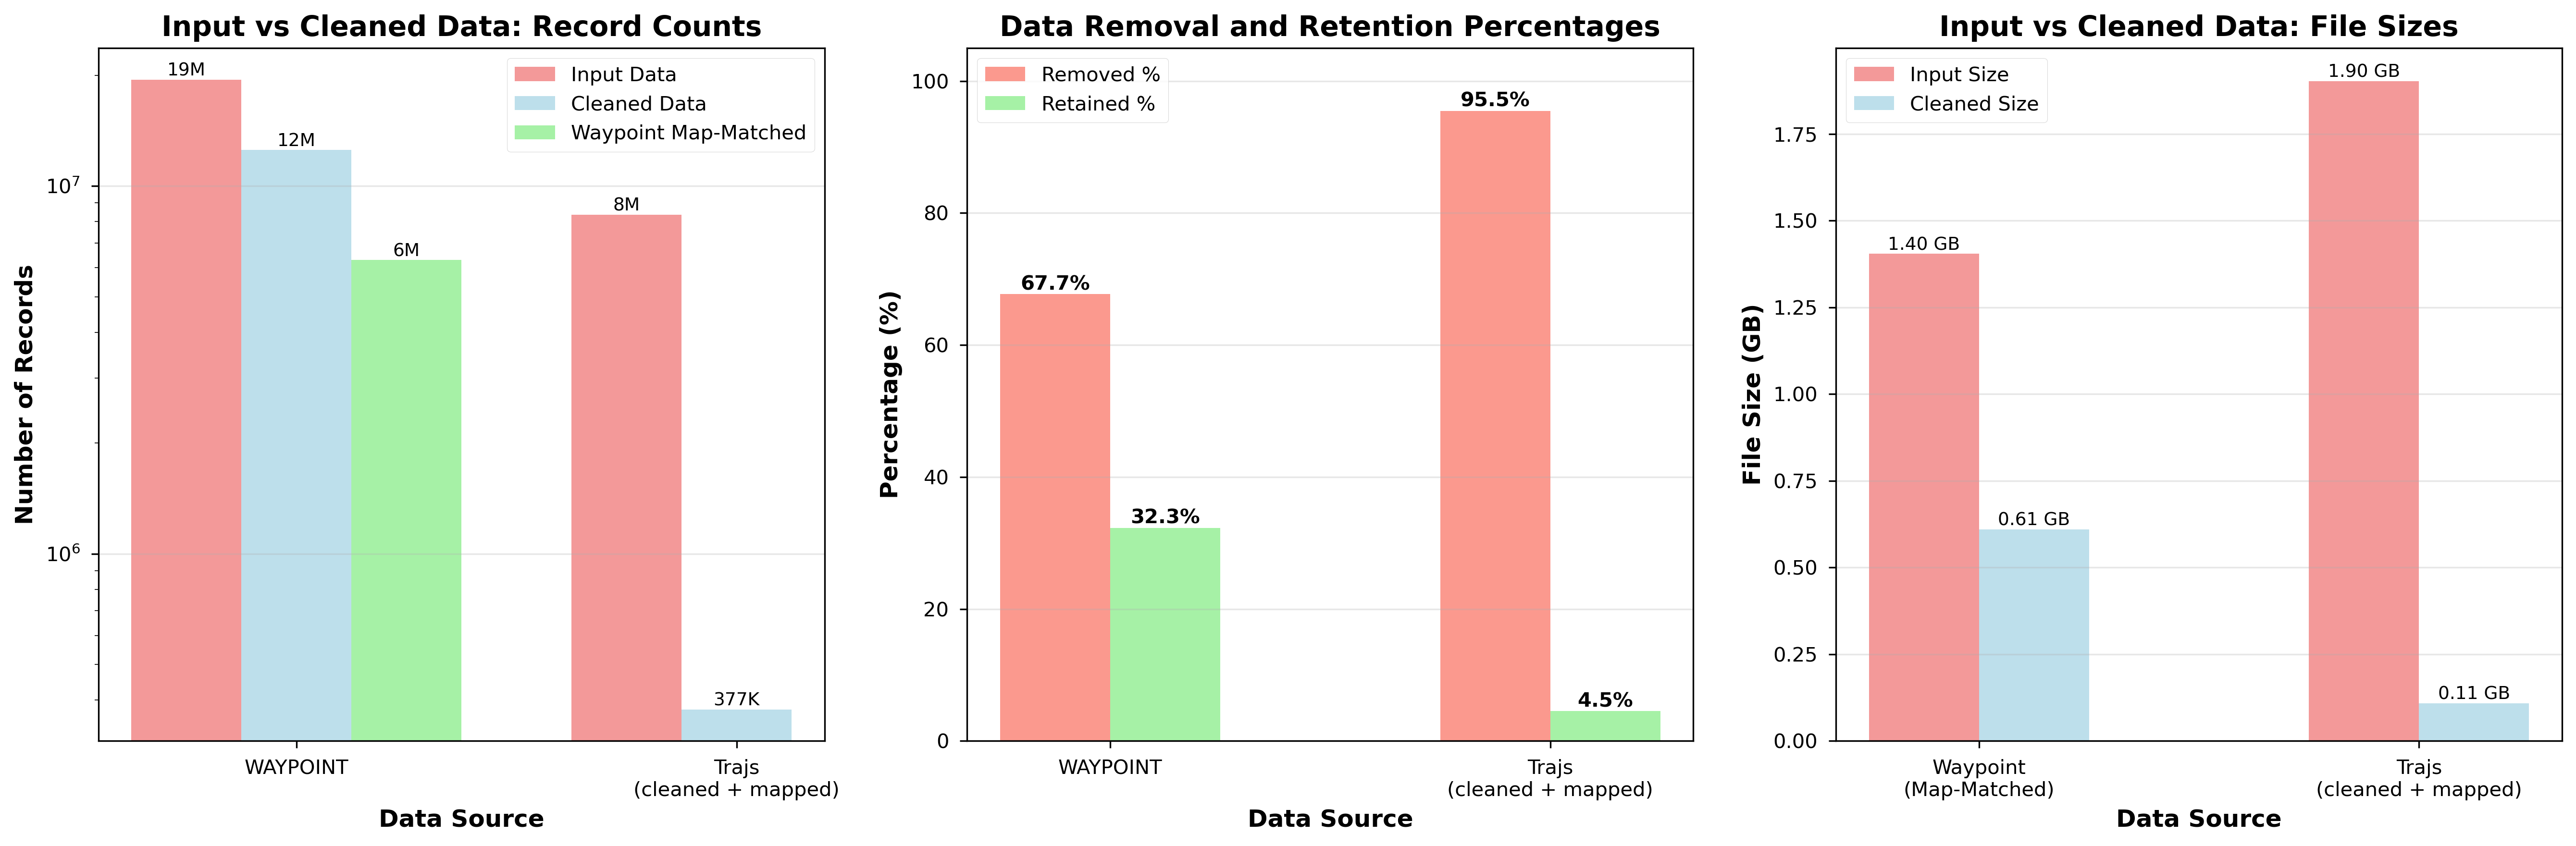

In [103]:
# Create visualizations comparing input vs cleaned data
if cleaning_impact:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Record Count Comparison (Bar Chart)
    ax1 = axes[0]
    sources = list(cleaning_impact.keys())
    input_counts = [cleaning_impact[s]['input_records'] for s in sources]
    cleaned_counts = [cleaning_impact[s]['cleaned_records'] for s in sources]
    
    # For waypoint, add map-matched count if available
    waypoint_matched_count = None
    if 'waypoint' in cleaning_impact and 'matched_records' in cleaning_impact['waypoint']:
        waypoint_matched_count = cleaning_impact['waypoint']['matched_records']
    
    x = np.arange(len(sources))
    width = 0.25 if waypoint_matched_count else 0.35
    
    bars1 = ax1.bar(x - width, input_counts, width, label='Input Data', color='lightcoral', alpha=0.8)
    bars2 = ax1.bar(x, cleaned_counts, width, label='Cleaned Data', color='lightblue', alpha=0.8)
    
    # Add waypoint map-matched bar if available
    if waypoint_matched_count:
        waypoint_idx = sources.index('waypoint')
        bars3 = ax1.bar(x[waypoint_idx] + width, waypoint_matched_count, width, 
                        label='Waypoint Map-Matched', color='lightgreen', alpha=0.8)
    
    ax1.set_xlabel('Data Source', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Number of Records', fontweight='bold', fontsize=12)
    ax1.set_title('Input vs Cleaned Data: Record Counts', fontweight='bold', fontsize=14)
    ax1.set_xticks(x)
    # Update labels: trajs -> trajs (cleaned + mapped)
    labels = []
    for s in sources:
        if s == 'trajs':
            labels.append('Trajs\n(cleaned + mapped)')
        else:
            labels.append(s.upper())
    ax1.set_xticklabels(labels)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_yscale('log')  # Log scale for better visualization
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height/1e6)}M' if height > 1e6 else f'{int(height/1e3)}K',
                    ha='center', va='bottom', fontsize=9)
    if waypoint_matched_count:
        for bar in bars3:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height/1e6)}M' if height > 1e6 else f'{int(height/1e3)}K',
                    ha='center', va='bottom', fontsize=9)
    
    # 2. Removal Percentage (Bar Chart) - Use waypoint_mapmatched for waypoint
    ax2 = axes[1]
    removal_pcts = []
    retention_pcts = []
    
    for s in sources:
        if s == 'waypoint' and 'final_retention_pct' in cleaning_impact[s]:
            # Use total removal from input to map-matched for waypoint
            final_retention = cleaning_impact[s]['final_retention_pct']
            removal_pcts.append(100 - final_retention)  # Total removal from input to map-matched
            retention_pcts.append(final_retention)  # Final retention from input to map-matched
        else:
            removal_pcts.append(cleaning_impact[s]['removal_percentage'])
            retention_pcts.append(cleaning_impact[s]['retention_percentage'])
    
    bars1 = ax2.bar(x - width/2, removal_pcts, width, label='Removed %', color='salmon', alpha=0.8)
    bars2 = ax2.bar(x + width/2, retention_pcts, width, label='Retained %', color='lightgreen', alpha=0.8)
    
    ax2.set_xlabel('Data Source', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Percentage (%)', fontweight='bold', fontsize=12)
    ax2.set_title('Data Removal and Retention Percentages', fontweight='bold', fontsize=14)
    ax2.set_xticks(x)
    # Update labels: trajs -> trajs (cleaned + mapped)
    labels = []
    for s in sources:
        if s == 'trajs':
            labels.append('Trajs\n(cleaned + mapped)')
        else:
            labels.append(s.upper())
    ax2.set_xticklabels(labels)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim([0, 105])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 3. File Size Comparison - Use waypoint_mapmatched for waypoint
    ax3 = axes[2]
    input_sizes = []
    cleaned_sizes = []
    labels = []
    
    # Use waypoint_mapmatched if available, otherwise fallback to waypoint_cleaned
    if 'waypoint' in input_stats:
        input_sizes.append(input_stats['waypoint']['file_size_gb'])
        if WAYPOINT_CLEANED_MATCHED.exists():
            cleaned_sizes.append(WAYPOINT_CLEANED_MATCHED.stat().st_size / (1024**3))
            labels.append('Waypoint\n(Map-Matched)')
        elif WAYPOINT_CLEANED.exists():
            cleaned_sizes.append(WAYPOINT_CLEANED.stat().st_size / (1024**3))
            labels.append('Waypoint')
    
    if 'trajs' in input_stats and TRAJS_CLEANED.exists():
        input_sizes.append(input_stats['trajs']['file_size_gb'])
        cleaned_sizes.append(TRAJS_CLEANED.stat().st_size / (1024**3))
        labels.append('Trajs\n(cleaned + mapped)')
    
    if input_sizes:
        x = np.arange(len(labels))
        bars1 = ax3.bar(x - width/2, input_sizes, width, label='Input Size', color='lightcoral', alpha=0.8)
        bars2 = ax3.bar(x + width/2, cleaned_sizes, width, label='Cleaned Size', color='lightblue', alpha=0.8)
        
        ax3.set_xlabel('Data Source', fontweight='bold', fontsize=12)
        ax3.set_ylabel('File Size (GB)', fontweight='bold', fontsize=12)
        ax3.set_title('Input vs Cleaned Data: File Sizes', fontweight='bold', fontsize=14)
        ax3.set_xticks(x)
        ax3.set_xticklabels(labels)
        ax3.legend()
        ax3.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f} GB',
                        ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'input_vs_cleaned_comparison.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Saved: input_vs_cleaned_comparison.png")
    plt.show()
else:
    print("⚠️  No cleaning impact data available for visualization")


### 0.3 Speed Distribution Comparison: Input vs Cleaned

Compare speed distributions between raw input data and cleaned data to assess the impact of outlier removal and filtering.



SPEED DISTRIBUTION COMPARISON: INPUT vs CLEANED

📊 Comparing waypoint speed distributions...
   Input: Mean=36.46, Median=37.00, Std=29.92
   Cleaned: Mean=45.08, Median=46.00, Std=24.49
   Map-Matched: Mean=49.05, Median=56.00, Std=24.57

📊 Comparing trip path speed distributions...
   Input: Mean=50.29, Median=53.57, Std=19.85
   Cleaned: Mean=54.95, Median=58.58, Std=16.32

✅ Saved: speed_distribution_input_vs_cleaned.png


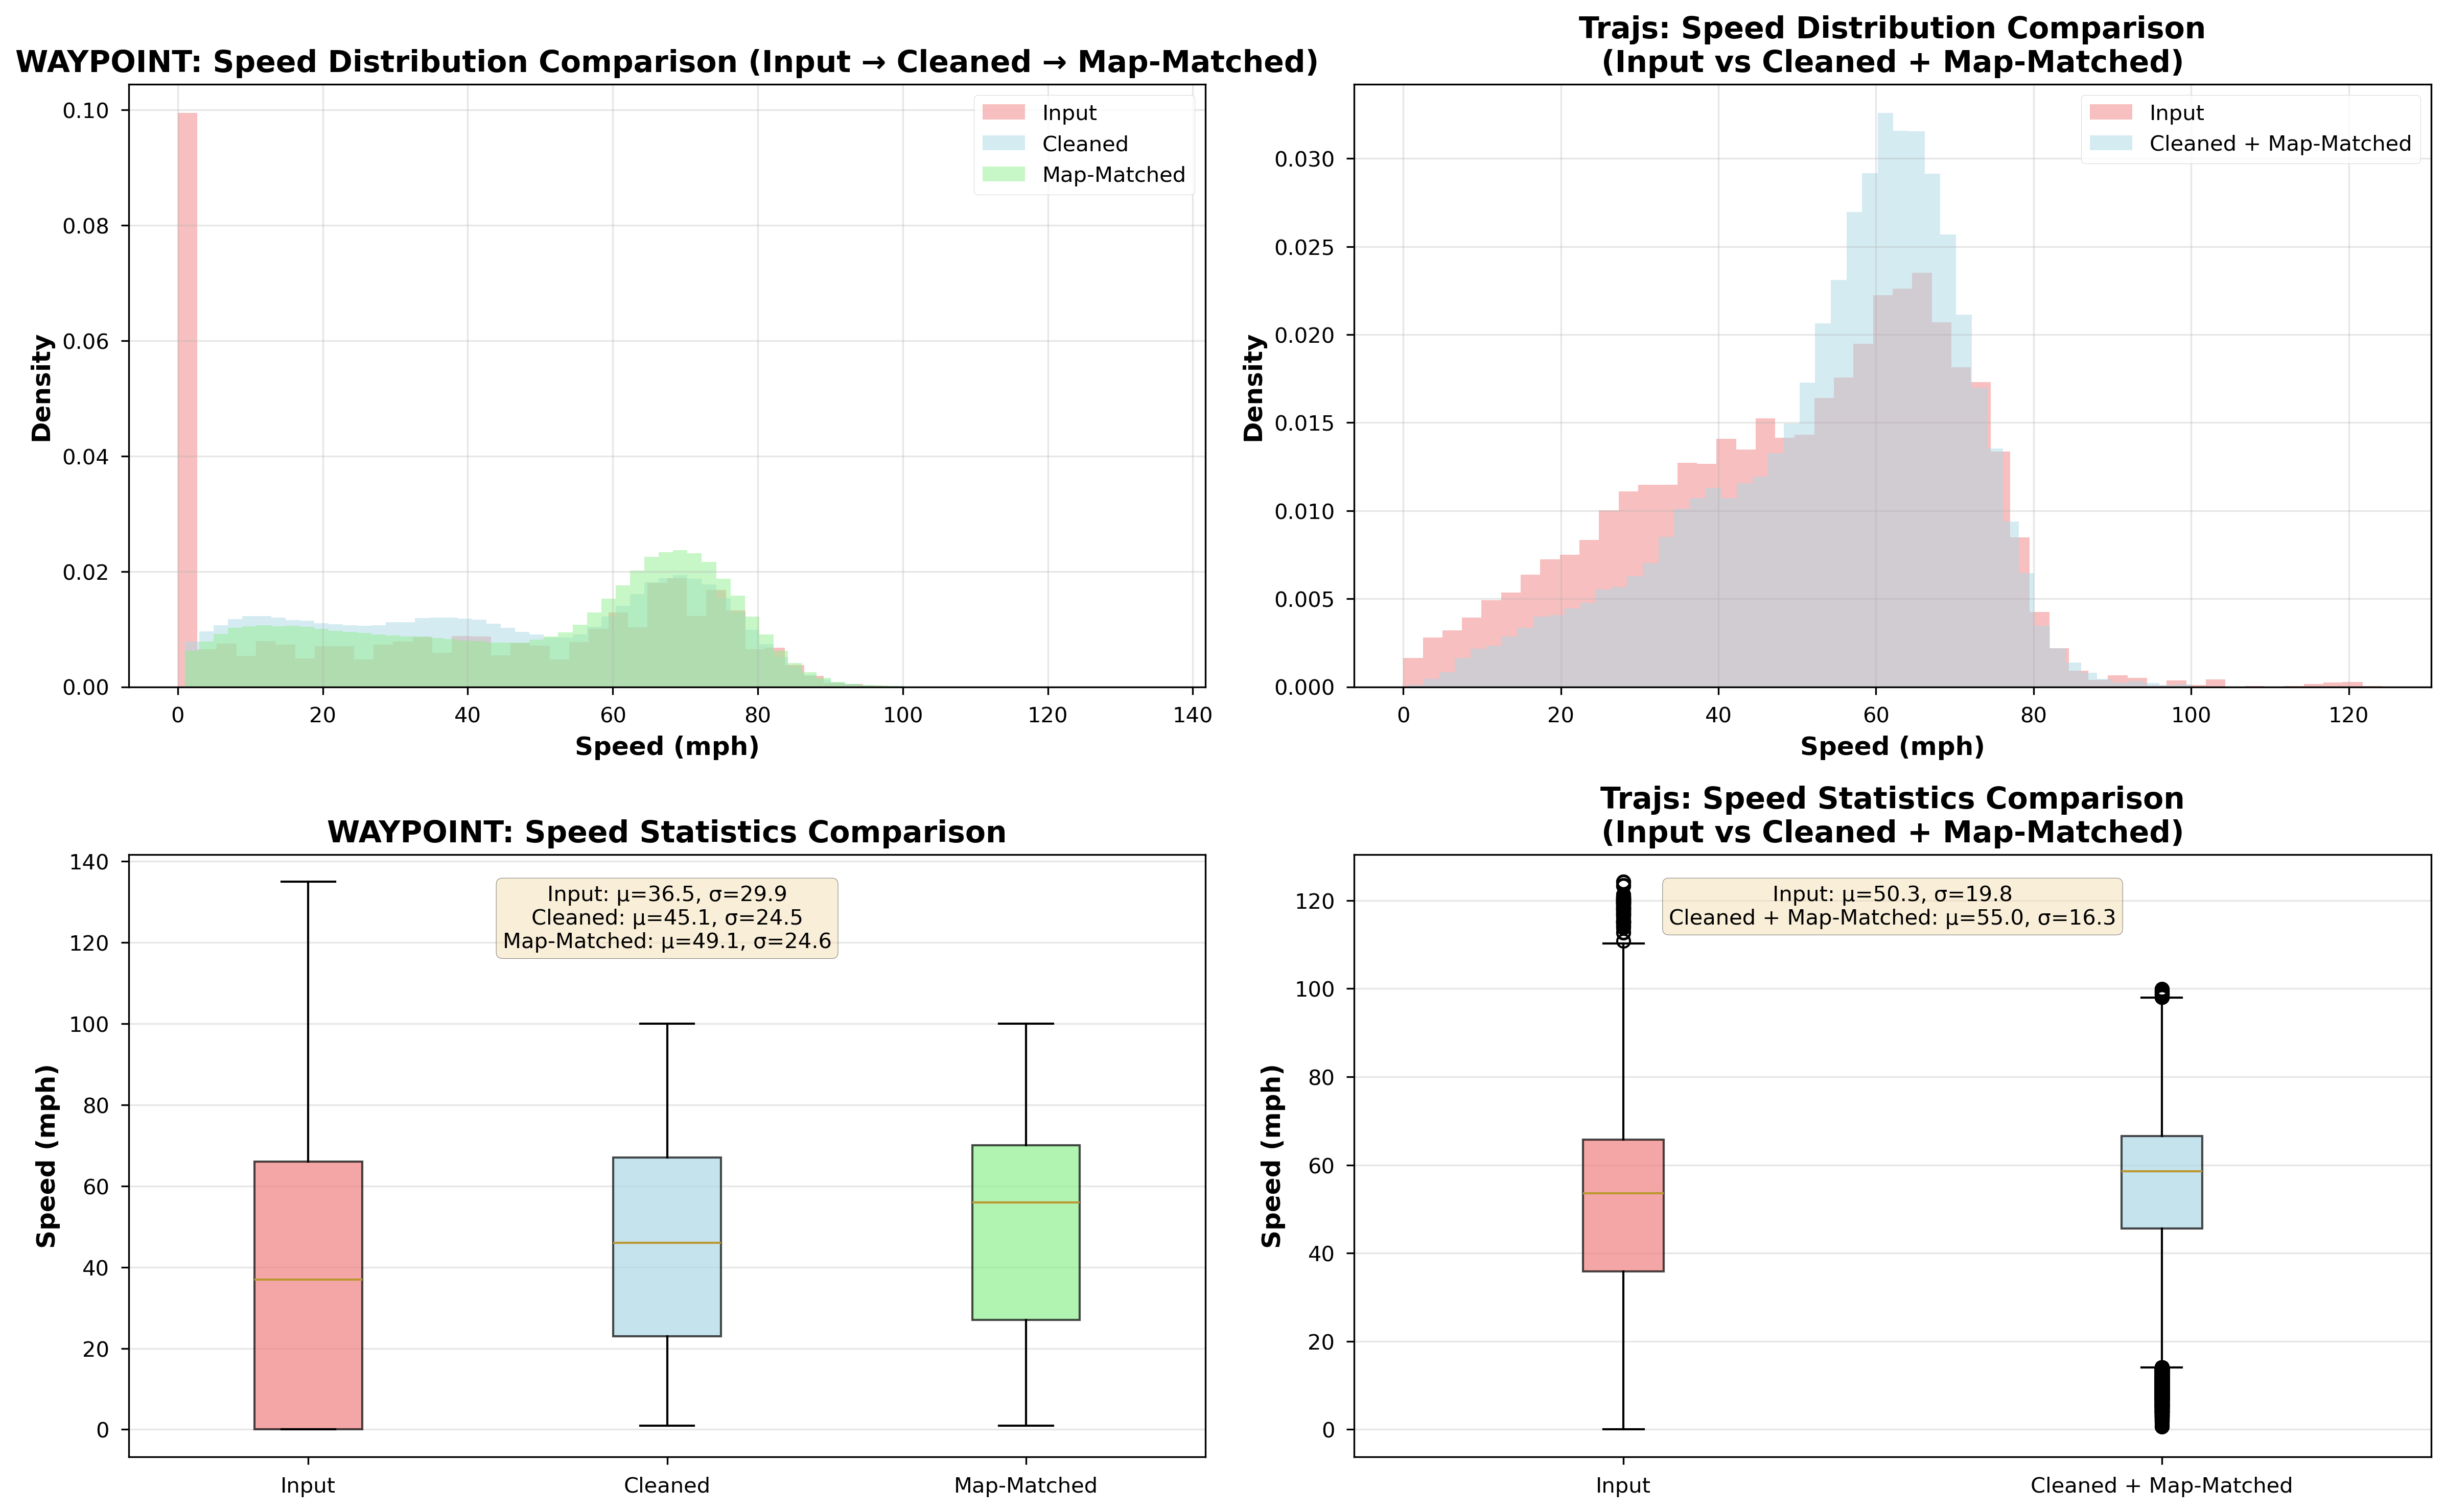

In [104]:
# Compare speed distributions between input and cleaned data
print("\n" + "="*80)
print("SPEED DISTRIBUTION COMPARISON: INPUT vs CLEANED")
print("="*80)

speed_comparison = {}

# Compare waypoint speeds
if WAYPOINT_RAW.exists() and WAYPOINT_CLEANED.exists() and 'waypoint' in input_stats:
    print("\n📊 Comparing waypoint speed distributions...")
    
    # Load sample from input data
    input_speeds = pd.read_csv(WAYPOINT_RAW, usecols=['speed_mph'], nrows=500000, low_memory=False)
    input_speeds = pd.to_numeric(input_speeds['speed_mph'], errors='coerce')
    input_speeds = input_speeds[(input_speeds.notna()) & (input_speeds >= 0) & (input_speeds <= 200)]
    
    # Load sample from cleaned data
    cleaned_speeds = pd.read_csv(WAYPOINT_CLEANED, usecols=['speed_mph'], nrows=500000, low_memory=False)
    cleaned_speeds = pd.to_numeric(cleaned_speeds['speed_mph'], errors='coerce')
    cleaned_speeds = cleaned_speeds[(cleaned_speeds.notna()) & (cleaned_speeds >= 0) & (cleaned_speeds <= 200)]
    
    speed_comparison['waypoint'] = {
        'input': input_speeds,
        'cleaned': cleaned_speeds,
        'input_mean': input_speeds.mean(),
        'cleaned_mean': cleaned_speeds.mean(),
        'input_std': input_speeds.std(),
        'cleaned_std': cleaned_speeds.std(),
        'input_median': input_speeds.median(),
        'cleaned_median': cleaned_speeds.median()
    }
    
    # Add map-matched waypoint speeds if available
    if WAYPOINT_CLEANED_MATCHED.exists():
        matched_speeds = pd.read_csv(WAYPOINT_CLEANED_MATCHED, usecols=['speed_mph'], nrows=500000, low_memory=False)
        matched_speeds = pd.to_numeric(matched_speeds['speed_mph'], errors='coerce')
        matched_speeds = matched_speeds[(matched_speeds.notna()) & (matched_speeds >= 0) & (matched_speeds <= 200)]
        speed_comparison['waypoint']['mapmatched'] = matched_speeds
        speed_comparison['waypoint']['mapmatched_mean'] = matched_speeds.mean()
        speed_comparison['waypoint']['mapmatched_std'] = matched_speeds.std()
        speed_comparison['waypoint']['mapmatched_median'] = matched_speeds.median()
    
    print(f"   Input: Mean={input_speeds.mean():.2f}, Median={input_speeds.median():.2f}, Std={input_speeds.std():.2f}")
    print(f"   Cleaned: Mean={cleaned_speeds.mean():.2f}, Median={cleaned_speeds.median():.2f}, Std={cleaned_speeds.std():.2f}")
    if 'mapmatched' in speed_comparison['waypoint']:
        print(f"   Map-Matched: Mean={speed_comparison['waypoint']['mapmatched_mean']:.2f}, Median={speed_comparison['waypoint']['mapmatched_median']:.2f}, Std={speed_comparison['waypoint']['mapmatched_std']:.2f}")

# Compare trip path speeds (if available in input)
if TRAJS_RAW.exists() and TRAJS_CLEANED.exists() and 'trajs' in input_stats:
    print("\n📊 Comparing trip path speed distributions...")
    
    try:
        # Load sample from input data (CrossingSpeedKph, column 15, index 14)
        input_speeds = pd.read_csv(TRAJS_RAW, usecols=[14], nrows=100000, low_memory=False, header=None)
        input_speeds.columns = ['CrossingSpeedKph']
        input_speeds['CrossingSpeedKph'] = pd.to_numeric(input_speeds['CrossingSpeedKph'], errors='coerce')
        input_speeds = input_speeds[(input_speeds['CrossingSpeedKph'].notna()) & 
                                    (input_speeds['CrossingSpeedKph'] >= 0) & 
                                    (input_speeds['CrossingSpeedKph'] <= 200)]
        # Convert to mph for comparison
        input_speeds_mph = input_speeds['CrossingSpeedKph'] * 0.621371
        
        # Load sample from cleaned data
        cleaned_speeds = pd.read_csv(TRAJS_CLEANED, usecols=['CrossingSpeedMph'], nrows=100000, low_memory=False)
        cleaned_speeds = pd.to_numeric(cleaned_speeds['CrossingSpeedMph'], errors='coerce')
        cleaned_speeds = cleaned_speeds[(cleaned_speeds.notna()) & 
                                        (cleaned_speeds >= 0) & 
                                        (cleaned_speeds <= 200)]
        
        speed_comparison['trajs'] = {
            'input': input_speeds_mph,
            'cleaned': cleaned_speeds,
            'input_mean': input_speeds_mph.mean(),
            'cleaned_mean': cleaned_speeds.mean(),
            'input_std': input_speeds_mph.std(),
            'cleaned_std': cleaned_speeds.std(),
            'input_median': input_speeds_mph.median(),
            'cleaned_median': cleaned_speeds.median(),
            'cleaned_label': 'Cleaned + Map-Matched'  # Label for trajs cleaned data
        }
        
        print(f"   Input: Mean={input_speeds_mph.mean():.2f}, Median={input_speeds_mph.median():.2f}, Std={input_speeds_mph.std():.2f}")
        print(f"   Cleaned: Mean={cleaned_speeds.mean():.2f}, Median={cleaned_speeds.median():.2f}, Std={cleaned_speeds.std():.2f}")
    except Exception as e:
        print(f"   ⚠️  Could not compare trip path speeds: {e}")

# Create visualization
if speed_comparison:
    fig, axes = plt.subplots(2, len(speed_comparison), figsize=(8*len(speed_comparison), 10))
    if len(speed_comparison) == 1:
        axes = axes.reshape(2, 1)
    
    for idx, (source, data) in enumerate(speed_comparison.items()):
        # Histogram comparison
        ax1 = axes[0, idx]
        ax1.hist(data['input'], bins=50, alpha=0.5, label='Input', color='lightcoral', density=True)
        # Use appropriate label for cleaned data
        cleaned_label = data.get('cleaned_label', 'Cleaned')
        ax1.hist(data['cleaned'], bins=50, alpha=0.5, label=cleaned_label, color='lightblue', density=True)
        if 'mapmatched' in data:
            ax1.hist(data['mapmatched'], bins=50, alpha=0.5, label='Map-Matched', color='lightgreen', density=True)
        ax1.set_xlabel('Speed (mph)', fontweight='bold', fontsize=12)
        ax1.set_ylabel('Density', fontweight='bold', fontsize=12)
        # Update title: Keep "Trajs" as name, but show cleaned + map-matched in subtitle
        if source == 'trajs':
            title = 'Trajs: Speed Distribution Comparison\n(Input vs Cleaned + Map-Matched)'
        else:
            title = f'{source.upper()}: Speed Distribution Comparison'
            if 'mapmatched' in data:
                title += ' (Input → Cleaned → Map-Matched)'
        ax1.set_title(title, fontweight='bold', fontsize=14)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Box plot comparison
        ax2 = axes[1, idx]
        box_data = [data['input'], data['cleaned']]
        # Use appropriate label for cleaned data
        cleaned_label = data.get('cleaned_label', 'Cleaned')
        box_labels = ['Input', cleaned_label]
        if 'mapmatched' in data:
            box_data.append(data['mapmatched'])
            box_labels.append('Map-Matched')
        bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightcoral')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor('lightblue')
        bp['boxes'][1].set_alpha(0.7)
        if len(bp['boxes']) > 2:
            bp['boxes'][2].set_facecolor('lightgreen')
            bp['boxes'][2].set_alpha(0.7)
        ax2.set_ylabel('Speed (mph)', fontweight='bold', fontsize=12)
        # Update title: Keep "Trajs" as name
        if source == 'trajs':
            title = 'Trajs: Speed Statistics Comparison\n(Input vs Cleaned + Map-Matched)'
        else:
            title = f'{source.upper()}: Speed Statistics Comparison'
        ax2.set_title(title, fontweight='bold', fontsize=14)
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add statistics text
        stats_text = f"Input: μ={data['input_mean']:.1f}, σ={data['input_std']:.1f}\n"
        cleaned_label = data.get('cleaned_label', 'Cleaned')
        stats_text += f"{cleaned_label}: μ={data['cleaned_mean']:.1f}, σ={data['cleaned_std']:.1f}"
        if 'mapmatched' in data:
            stats_text += f"\nMap-Matched: μ={data['mapmatched_mean']:.1f}, σ={data['mapmatched_std']:.1f}"
        ax2.text(0.5, 0.95, stats_text, transform=ax2.transAxes,
                fontsize=10, verticalalignment='top', ha='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'speed_distribution_input_vs_cleaned.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Saved: speed_distribution_input_vs_cleaned.png")
    plt.show()
else:
    print("⚠️  No speed comparison data available")


---

## 1. Data Quality Metrics {#quality}

### Purpose
This section calculates and visualizes data quality metrics including:
- **Completeness**: Percentage of non-missing values for key columns
- **Data Quality Assessment**: Before and after cleaning comparisons
- **Quality Metrics Summary**: Comprehensive tables for reporting

### Key Metrics
- Completeness percentage per column
- Missing data counts
- Data quality thresholds (99% completeness target)


In [105]:
# Load cleaned data files
print("\n📂 Loading cleaned data files...")

# Function to calculate completeness
def calculate_completeness(df, columns):
    """Calculate completeness percentage for specified columns."""
    results = {}
    total_rows = len(df)
    
    for col in columns:
        if col in df.columns:
            non_missing = df[col].notna().sum()
            completeness = (non_missing / total_rows * 100) if total_rows > 0 else 0
            results[col] = {
                'completeness': completeness,
                'non_missing': non_missing,
                'missing': total_rows - non_missing,
                'total': total_rows
            }
    return results

# Calculate completeness for each cleaned data file
completeness_results = {}

# Use waypoint_mapmatched for final corridor analysis (Section 1, 2, 3)
if WAYPOINT_CLEANED_MATCHED.exists():
    print("\n📊 Loading waypoint map-matched data (final corridor dataset)...")
    waypoint_df = pd.read_csv(WAYPOINT_CLEANED_MATCHED, low_memory=False)
    key_cols = ['journey_id', 'capture_time', 'latitude', 'longitude', 'speed_mph', 'local_time']
    completeness_results['waypoint_mapmatched'] = calculate_completeness(waypoint_df, key_cols)
    print(f"   Analyzed {len(waypoint_df):,} waypoint map-matched records")
    del waypoint_df  # Free memory
elif WAYPOINT_CLEANED.exists():
    print("\n📊 Loading waypoint cleaned data (fallback if map-matched not available)...")
    waypoint_df = pd.read_csv(WAYPOINT_CLEANED, low_memory=False)
    key_cols = ['journey_id', 'capture_time', 'latitude', 'longitude', 'speed_mph', 'local_time']
    completeness_results['waypoint'] = calculate_completeness(waypoint_df, key_cols)
    print(f"   Analyzed {len(waypoint_df):,} waypoint records")
    del waypoint_df  # Free memory

if TRAJS_CLEANED.exists():
    print("📊 Loading trip path cleaned data (cleaned + mapped by SegmentId_to_link.csv)...")
    trajs_df = pd.read_csv(TRAJS_CLEANED, low_memory=False)
    key_cols = ['SegmentId', 'CrossingStartDateLocal', 'CrossingEndDateLocal', 'CrossingSpeedMph']
    completeness_results['trajs'] = calculate_completeness(trajs_df, key_cols)
    print(f"   Analyzed {len(trajs_df):,} trip path records (cleaned + mapped)")
    del trajs_df  # Free memory

# Create completeness summary table
completeness_summary = []
for table, cols in completeness_results.items():
    for col, metrics in cols.items():
        completeness_summary.append({
            'Data Source': table,
            'Column': col,
            'Completeness (%)': metrics['completeness'],
            'Non-Missing': metrics['non_missing'],
            'Missing': metrics['missing'],
            'Total': metrics['total']
        })

completeness_df = pd.DataFrame(completeness_summary)
# Convert completeness to float for proper formatting
completeness_df['Completeness (%)'] = completeness_df['Completeness (%)'].astype(float)
completeness_df['Non-Missing'] = completeness_df['Non-Missing'].astype(int)
completeness_df['Missing'] = completeness_df['Missing'].astype(int)
completeness_df['Total'] = completeness_df['Total'].astype(int)

print("\n" + "="*80)
print("DATA COMPLETENESS METRICS")
print("="*80)
print(completeness_df.to_string(index=False))

# Save to CSV
completeness_df.to_csv(METRICS_PATH / "completeness_metrics.csv", index=False)
print(f"\n✅ Saved: completeness_metrics.csv")



📂 Loading cleaned data files...

📊 Loading waypoint map-matched data (final corridor dataset)...
   Analyzed 6,288,904 waypoint map-matched records
📊 Loading trip path cleaned data (cleaned + mapped by SegmentId_to_link.csv)...
   Analyzed 377,563 trip path records (cleaned + mapped)

DATA COMPLETENESS METRICS
        Data Source                 Column  Completeness (%)  Non-Missing  Missing   Total
waypoint_mapmatched             journey_id             100.0      6288904        0 6288904
waypoint_mapmatched           capture_time             100.0      6288904        0 6288904
waypoint_mapmatched               latitude             100.0      6288904        0 6288904
waypoint_mapmatched              longitude             100.0      6288904        0 6288904
waypoint_mapmatched              speed_mph             100.0      6288904        0 6288904
waypoint_mapmatched             local_time             100.0      6288904        0 6288904
              trajs              SegmentId        

### 1.1 Completeness Visualization

Visual representation of data completeness across sources and columns.


✅ Saved: completeness_analysis.png


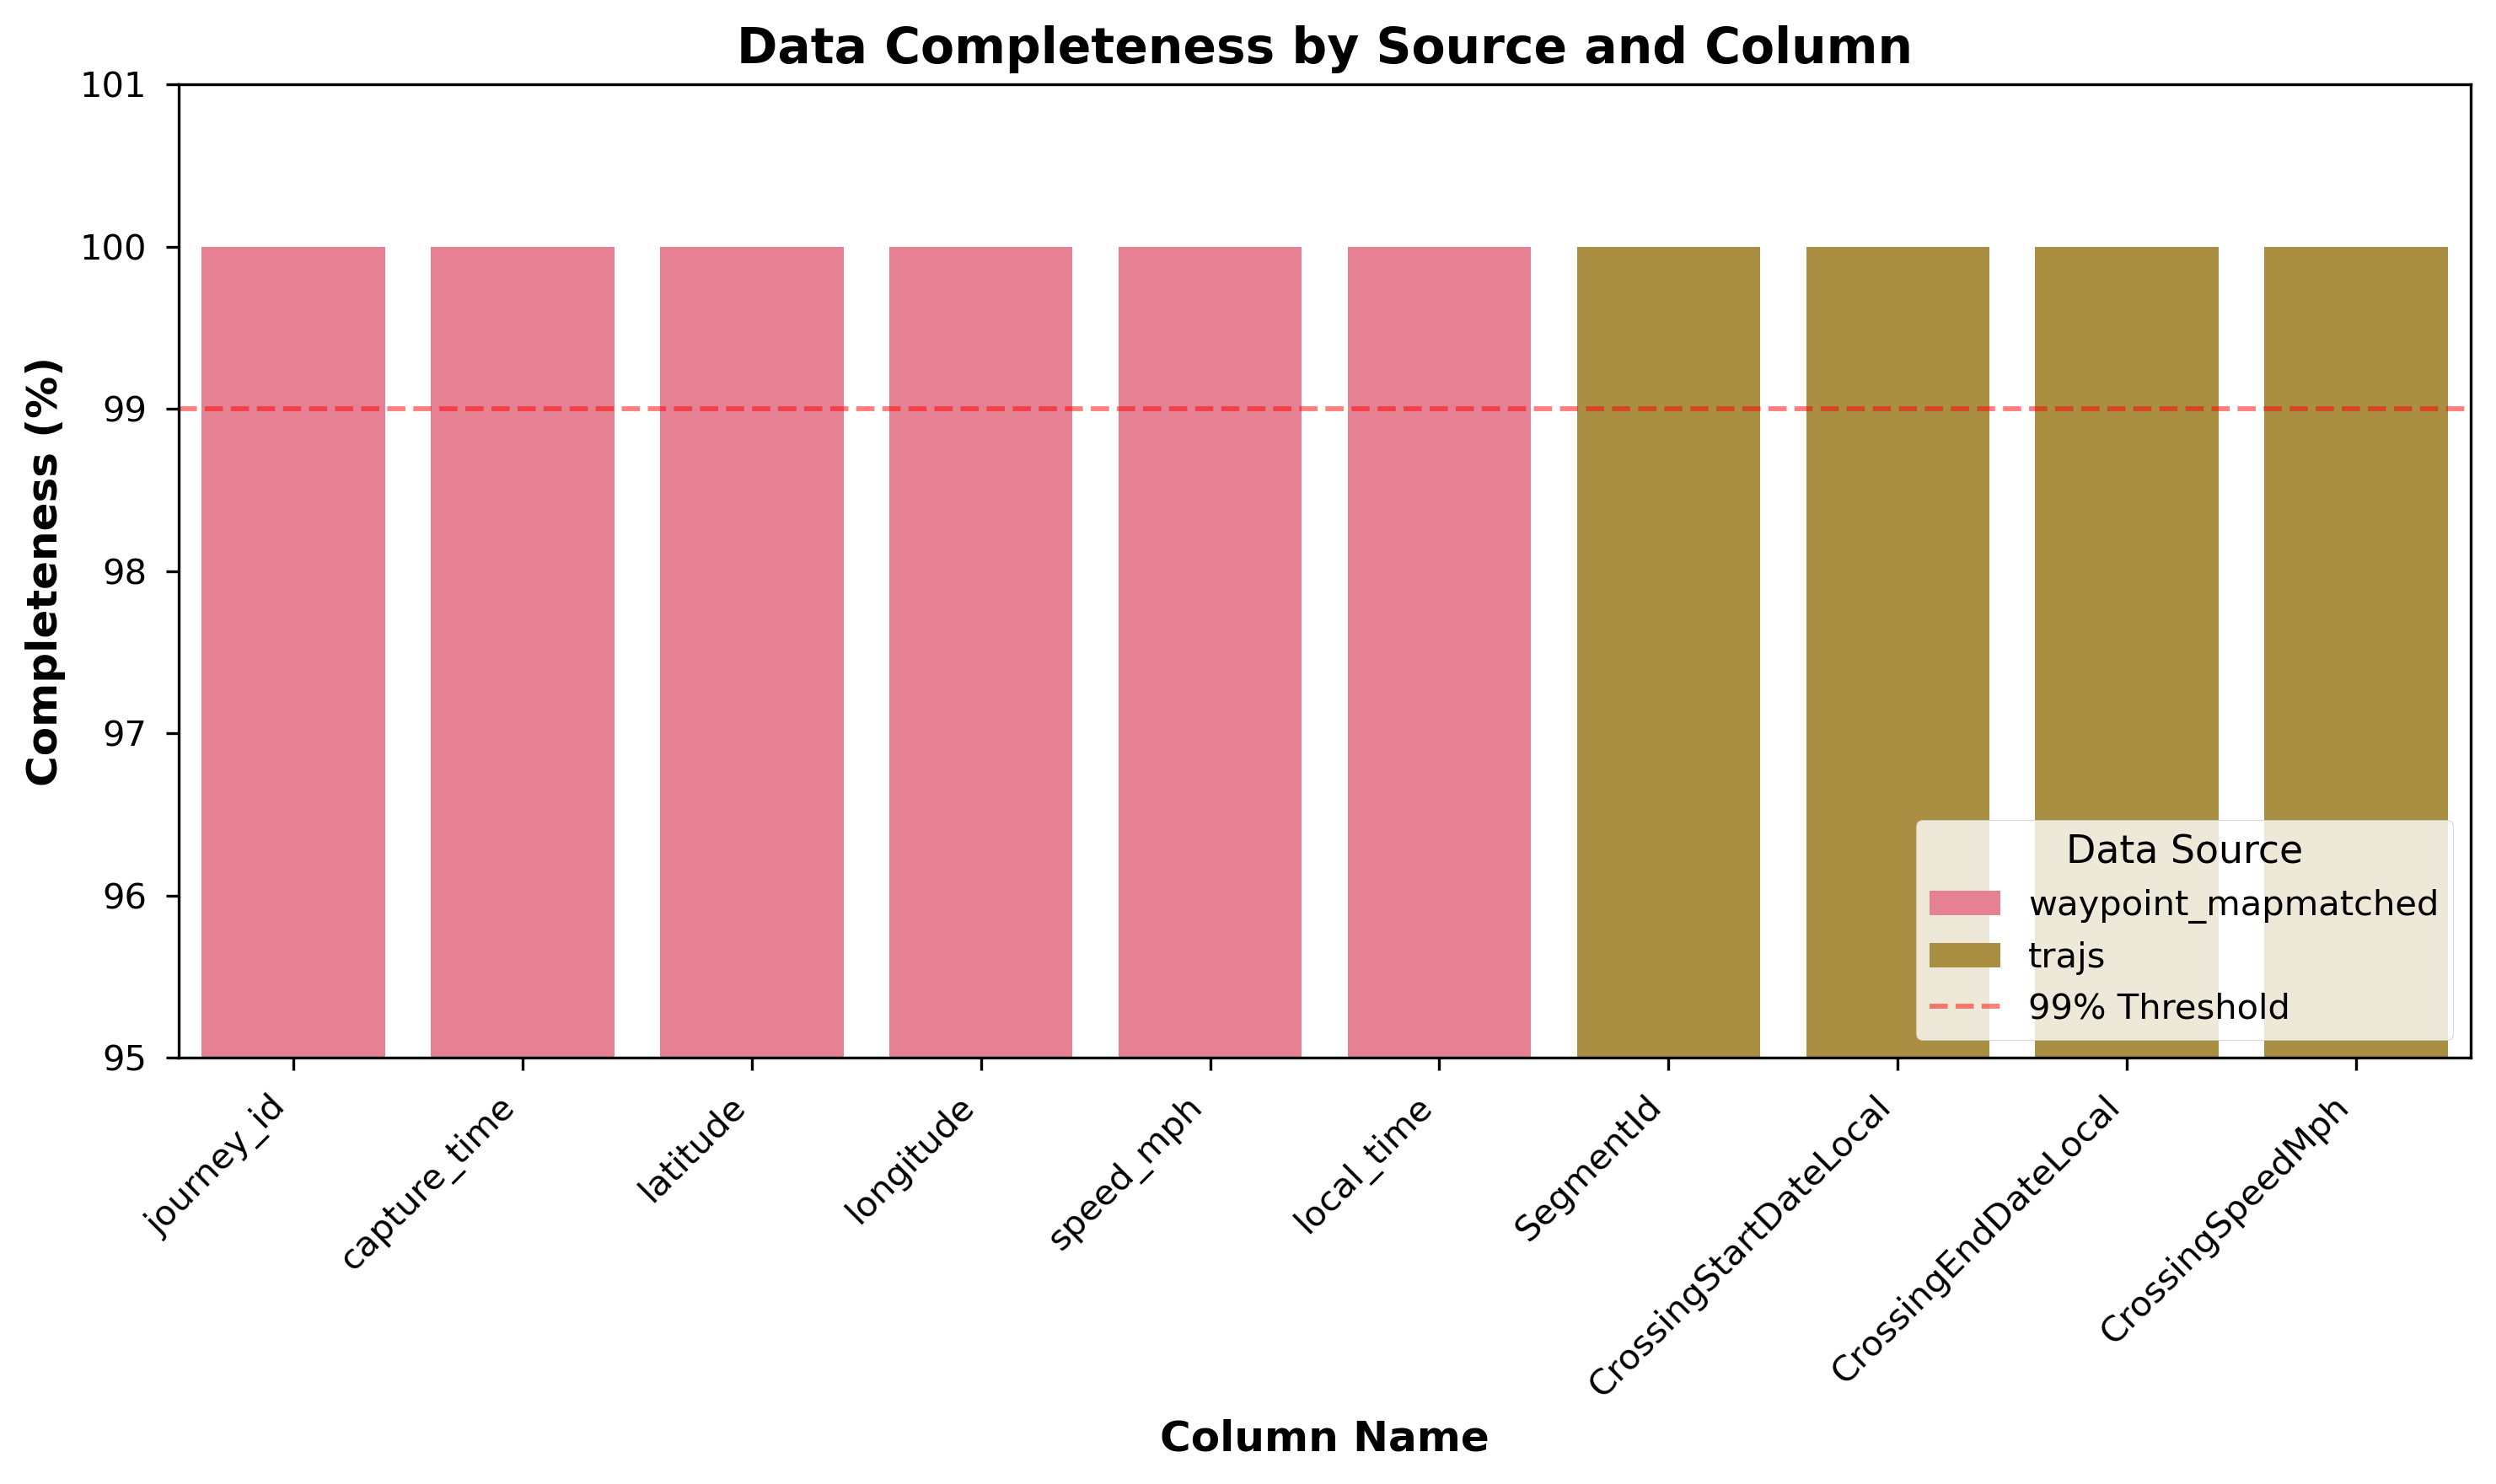

In [106]:
# Create completeness visualizations
fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

# Bar plot
completeness_pct = completeness_df.copy()
sns.barplot(data=completeness_pct, x='Column', y='Completeness (%)', hue='Data Source', ax=ax1)
ax1.set_title('Data Completeness by Source and Column', fontweight='bold', fontsize=14)
ax1.set_xlabel('Column Name', fontweight='bold')
ax1.set_ylabel('Completeness (%)', fontweight='bold')
ax1.axhline(y=99.0, color='red', linestyle='--', alpha=0.5, label='99% Threshold')
ax1.legend(title='Data Source', loc='lower right')
ax1.set_ylim([95, 101])
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'completeness_analysis.png', dpi=300, bbox_inches='tight')
print(f"✅ Saved: completeness_analysis.png")
plt.show()


---

## 2. Speed Distribution Analysis {#speed}

### Purpose
This section analyzes speed distributions across data sources to:
- Compare statistical properties (mean, median, std dev)
- Identify distribution patterns
- Validate data consistency across sources

### Key Statistics
- Mean, median, standard deviation
- Quartiles (Q25, Q75)
- Min/Max values
- Distribution shapes


In [107]:
# Analyze speed distributions
print("\n" + "="*80)
print("SPEED DISTRIBUTION ANALYSIS")
print("="*80)

speed_stats = {}

# Use waypoint_mapmatched for final corridor analysis (Section 2)
if WAYPOINT_CLEANED_MATCHED.exists():
    print("\n📊 Analyzing waypoint speeds from map-matched data (final corridor dataset)...")
    waypoint_df = pd.read_csv(WAYPOINT_CLEANED_MATCHED, usecols=['speed_mph'], low_memory=False)
    waypoint_df = waypoint_df[(waypoint_df['speed_mph'].notna()) & 
                               (waypoint_df['speed_mph'] >= 0) & 
                               (waypoint_df['speed_mph'] <= 200)]
    
    if len(waypoint_df) > 0:
        speed_stats['waypoint_mapmatched'] = {
            'mean': waypoint_df['speed_mph'].mean(),
            'median': waypoint_df['speed_mph'].median(),
            'std': waypoint_df['speed_mph'].std(),
            'min': waypoint_df['speed_mph'].min(),
            'max': waypoint_df['speed_mph'].max(),
            'q25': waypoint_df['speed_mph'].quantile(0.25),
            'q75': waypoint_df['speed_mph'].quantile(0.75),
            'count': len(waypoint_df),
            'data': waypoint_df['speed_mph'].values
        }
        print(f"   Analyzed {len(waypoint_df):,} map-matched speed records")
    del waypoint_df  # Free memory
elif WAYPOINT_CLEANED.exists():
    print("\n📊 Analyzing waypoint speeds from cleaned data (fallback if map-matched not available)...")
    waypoint_df = pd.read_csv(WAYPOINT_CLEANED, usecols=['speed_mph'], low_memory=False)
    waypoint_df = waypoint_df[(waypoint_df['speed_mph'].notna()) & 
                               (waypoint_df['speed_mph'] >= 0) & 
                               (waypoint_df['speed_mph'] <= 200)]
    
    if len(waypoint_df) > 0:
        speed_stats['waypoint'] = {
            'mean': waypoint_df['speed_mph'].mean(),
            'median': waypoint_df['speed_mph'].median(),
            'std': waypoint_df['speed_mph'].std(),
            'min': waypoint_df['speed_mph'].min(),
            'max': waypoint_df['speed_mph'].max(),
            'q25': waypoint_df['speed_mph'].quantile(0.25),
            'q75': waypoint_df['speed_mph'].quantile(0.75),
            'count': len(waypoint_df),
            'data': waypoint_df['speed_mph'].values
        }
        print(f"   Analyzed {len(waypoint_df):,} speed records")
    del waypoint_df  # Free memory

if TRAJS_CLEANED.exists():
    print("📊 Analyzing trip path speeds from cleaned data (cleaned + mapped by SegmentId_to_link.csv)...")
    trajs_df = pd.read_csv(TRAJS_CLEANED, usecols=['CrossingSpeedMph'], low_memory=False)
    trajs_df = trajs_df[(trajs_df['CrossingSpeedMph'].notna()) & 
                        (trajs_df['CrossingSpeedMph'] >= 0) & 
                        (trajs_df['CrossingSpeedMph'] <= 200)]
    
    if len(trajs_df) > 0:
        speed_stats['trajs'] = {
            'mean': trajs_df['CrossingSpeedMph'].mean(),
            'median': trajs_df['CrossingSpeedMph'].median(),
            'std': trajs_df['CrossingSpeedMph'].std(),
            'min': trajs_df['CrossingSpeedMph'].min(),
            'max': trajs_df['CrossingSpeedMph'].max(),
            'q25': trajs_df['CrossingSpeedMph'].quantile(0.25),
            'q75': trajs_df['CrossingSpeedMph'].quantile(0.75),
            'count': len(trajs_df),
            'data': trajs_df['CrossingSpeedMph'].values
        }
        print(f"   Analyzed {len(trajs_df):,} speed records (cleaned + mapped)")
    del trajs_df  # Free memory

# Create speed statistics table
stats_summary = []
for source, stats_dict in speed_stats.items():
    stats_summary.append({
        'Data Source': source,
        'Count': f"{stats_dict['count']:,}",
        'Mean (mph)': f"{stats_dict['mean']:.2f}",
        'Median (mph)': f"{stats_dict['median']:.2f}",
        'Std Dev (mph)': f"{stats_dict['std']:.2f}",
        'Min (mph)': f"{stats_dict['min']:.2f}",
        'Max (mph)': f"{stats_dict['max']:.2f}",
        'Q25 (mph)': f"{stats_dict['q25']:.2f}",
        'Q75 (mph)': f"{stats_dict['q75']:.2f}"
    })

stats_df = pd.DataFrame(stats_summary)
print("\nSPEED STATISTICS SUMMARY")
print("="*80)
print(stats_df.to_string(index=False))

# Save to CSV
stats_df.to_csv(METRICS_PATH / "speed_statistics.csv", index=False)
print(f"\n✅ Saved: speed_statistics.csv")



SPEED DISTRIBUTION ANALYSIS

📊 Analyzing waypoint speeds from map-matched data (final corridor dataset)...
   Analyzed 6,288,904 map-matched speed records
📊 Analyzing trip path speeds from cleaned data (cleaned + mapped by SegmentId_to_link.csv)...
   Analyzed 377,563 speed records (cleaned + mapped)

SPEED STATISTICS SUMMARY
        Data Source     Count Mean (mph) Median (mph) Std Dev (mph) Min (mph) Max (mph) Q25 (mph) Q75 (mph)
waypoint_mapmatched 6,288,904      47.53        52.00         23.00      1.00    100.00     28.00     67.00
              trajs   377,563      54.98        58.58         16.23      0.45     99.97     45.62     66.58

✅ Saved: speed_statistics.csv


### 2.1 Speed Distribution Visualizations

Comprehensive visualization of speed distributions including histograms, box plots, CDFs, and statistical summaries.


✅ Saved: speed_distribution_analysis.png


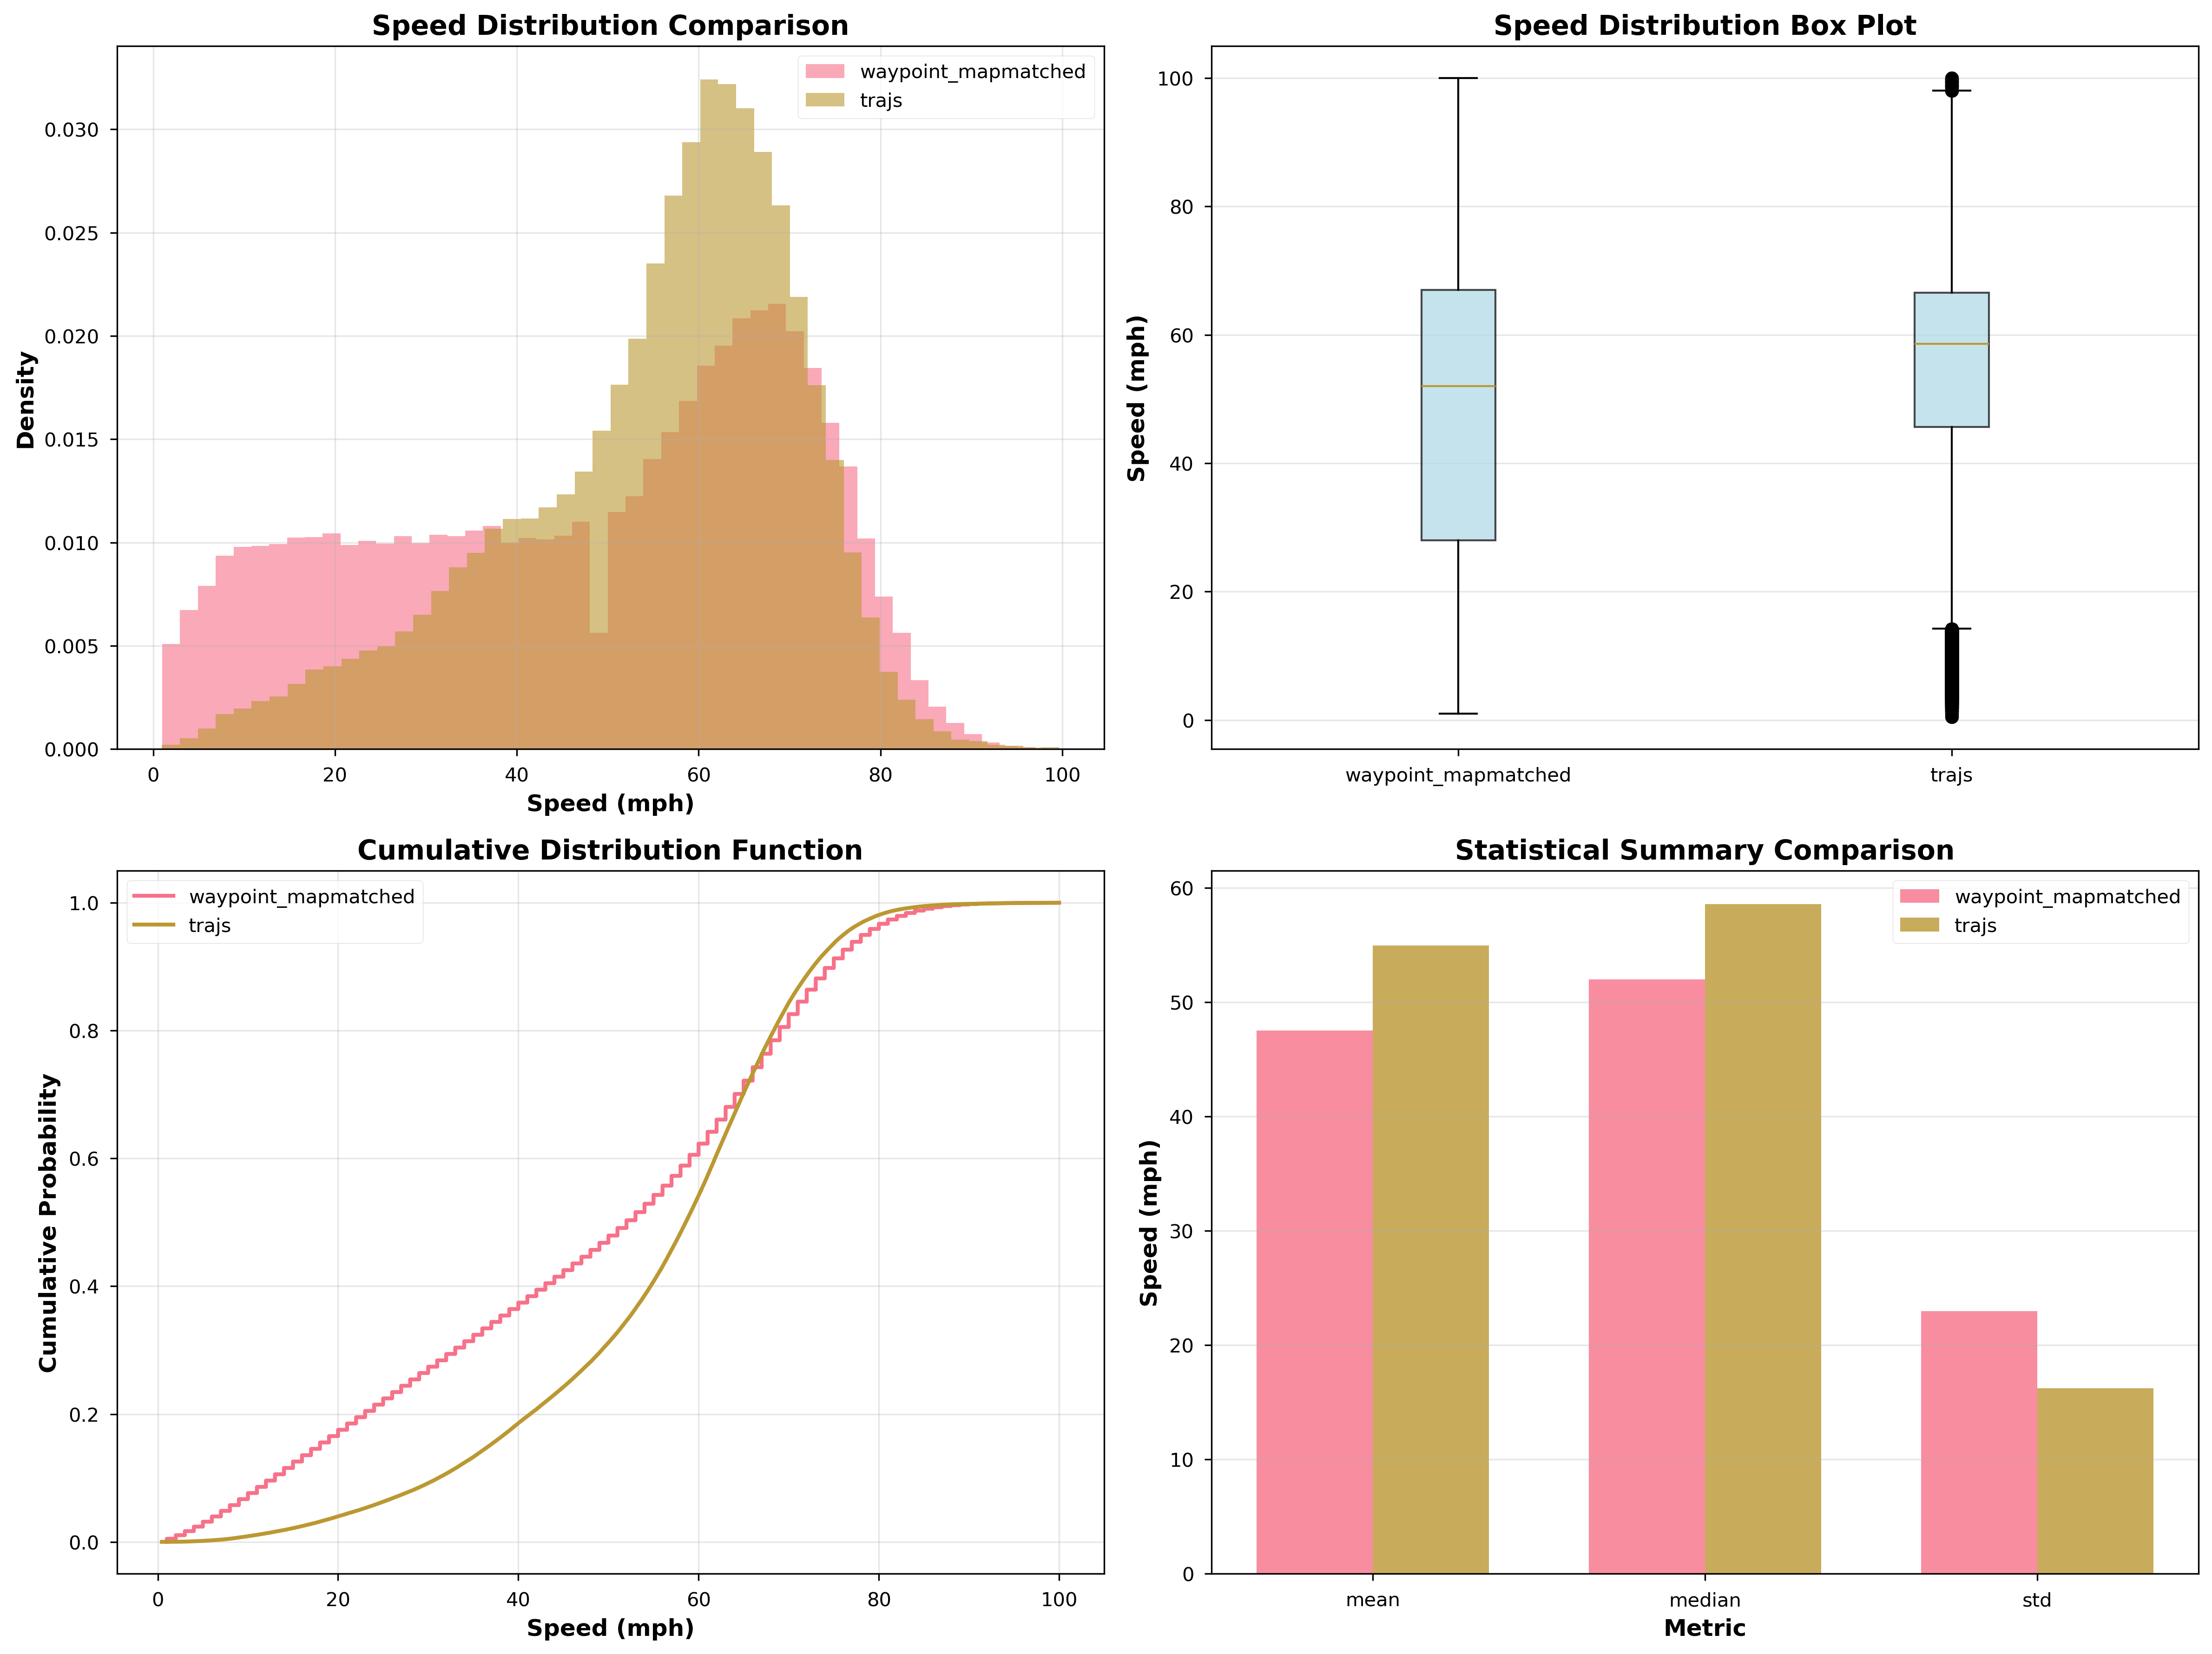

In [108]:
# Create comprehensive speed distribution visualizations
if len(speed_stats) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Histogram
    ax1 = axes[0, 0]
    for source, stats_dict in speed_stats.items():
        # Sample data for faster plotting if too large
        data = stats_dict['data']
        if len(data) > 100000:
            data = np.random.choice(data, 100000, replace=False)
        ax1.hist(data, bins=50, alpha=0.6, label=source, density=True)
    ax1.set_xlabel('Speed (mph)', fontweight='bold')
    ax1.set_ylabel('Density', fontweight='bold')
    ax1.set_title('Speed Distribution Comparison', fontweight='bold', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Box plot
    ax2 = axes[0, 1]
    box_data = [stats_dict['data'] for stats_dict in speed_stats.values()]
    box_labels = list(speed_stats.keys())
    bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    ax2.set_ylabel('Speed (mph)', fontweight='bold')
    ax2.set_title('Speed Distribution Box Plot', fontweight='bold', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # CDF
    ax3 = axes[1, 0]
    for source, stats_dict in speed_stats.items():
        sorted_data = np.sort(stats_dict['data'])
        # Sample for faster plotting
        if len(sorted_data) > 100000:
            indices = np.linspace(0, len(sorted_data)-1, 100000, dtype=int)
            sorted_data = sorted_data[indices]
        cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax3.plot(sorted_data, cumulative, label=source, linewidth=2)
    ax3.set_xlabel('Speed (mph)', fontweight='bold')
    ax3.set_ylabel('Cumulative Probability', fontweight='bold')
    ax3.set_title('Cumulative Distribution Function', fontweight='bold', fontsize=14)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Statistical summary
    ax4 = axes[1, 1]
    summary_metrics = ['mean', 'median', 'std']
    x = np.arange(len(summary_metrics))
    width = 0.35
    for i, (source, stats_dict) in enumerate(speed_stats.items()):
        values = [stats_dict['mean'], stats_dict['median'], stats_dict['std']]
        ax4.bar(x + i*width, values, width, label=source, alpha=0.8)
    ax4.set_xlabel('Metric', fontweight='bold')
    ax4.set_ylabel('Speed (mph)', fontweight='bold')
    ax4.set_title('Statistical Summary Comparison', fontweight='bold', fontsize=14)
    ax4.set_xticks(x + width/2)
    ax4.set_xticklabels(summary_metrics)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'speed_distribution_analysis.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved: speed_distribution_analysis.png")
    plt.show()


---

## 3. Performance Metrics & Cross-Source Validation {#performance}

### Purpose
This section calculates performance metrics for cross-source validation:
- **RMSE** (Root Mean Squared Error): Measures average prediction error
- **MAPE** (Mean Absolute Percentage Error): Percentage-based error metric
- **R²** (Coefficient of Determination): Measures goodness of fit
- **MAE** (Mean Absolute Error): Average absolute difference

### Validation Approach
Compares aggregated speeds from different data sources (waypoint vs trip path) to assess data consistency and quality.


In [109]:
# Function to calculate performance metrics
def calculate_metrics(y_true, y_pred):
    """Calculate RMSE, MAPE, R², and MAE."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    return {
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2,
        'MAE': mae
    }

print("\n" + "="*80)
print("PERFORMANCE METRICS & CROSS-SOURCE VALIDATION")
print("="*80)

performance_metrics = {}

if (WAYPOINT_CLEANED_MATCHED.exists() or WAYPOINT_CLEANED.exists()) and TRAJS_CLEANED.exists():
    print("\n📊 Aggregating speeds by hour for comparison...")
    
    # Load and aggregate waypoint speeds by hour (use map-matched for final corridor analysis)
    if WAYPOINT_CLEANED_MATCHED.exists():
        print("   Loading waypoint map-matched data (final corridor dataset)...")
        waypoint_df = pd.read_csv(WAYPOINT_CLEANED_MATCHED, usecols=['local_time', 'speed_mph'], low_memory=False)
    elif WAYPOINT_CLEANED.exists():
        print("   Loading waypoint cleaned data (fallback if map-matched not available)...")
        waypoint_df = pd.read_csv(WAYPOINT_CLEANED, usecols=['local_time', 'speed_mph'], low_memory=False)
    else:
        print("⚠️  Waypoint data not found")
        waypoint_df = None
    
    if waypoint_df is not None:
        waypoint_df = waypoint_df[(waypoint_df['speed_mph'].notna()) & 
                                    (waypoint_df['speed_mph'] >= 0) & 
                                    (waypoint_df['speed_mph'] <= 100)]
        waypoint_df['local_time'] = pd.to_datetime(waypoint_df['local_time'], errors='coerce')
        waypoint_df = waypoint_df[waypoint_df['local_time'].notna()]
        waypoint_df['hour'] = waypoint_df['local_time'].dt.floor('H')
        waypoint_hourly = waypoint_df.groupby('hour')['speed_mph'].mean().reset_index()
        waypoint_hourly.columns = ['hour', 'avg_speed']
        waypoint_hourly['hour'] = waypoint_hourly['hour'].dt.strftime('%Y-%m-%d %H:00:00')
        del waypoint_df  # Free memory
    else:
        waypoint_hourly = None
    
    # Load and aggregate trip path speeds by hour (cleaned + mapped by SegmentId_to_link.csv)
    print("   Loading trip path cleaned data (cleaned + mapped by SegmentId_to_link.csv)...")
    trajs_df = pd.read_csv(TRAJS_CLEANED, usecols=['CrossingStartDateLocal', 'CrossingSpeedMph'], low_memory=False)
    trajs_df = trajs_df[(trajs_df['CrossingSpeedMph'].notna()) & 
                        (trajs_df['CrossingSpeedMph'] >= 0) & 
                        (trajs_df['CrossingSpeedMph'] <= 100)]
    trajs_df['CrossingStartDateLocal'] = pd.to_datetime(trajs_df['CrossingStartDateLocal'], errors='coerce')
    trajs_df = trajs_df[trajs_df['CrossingStartDateLocal'].notna()]
    trajs_df['hour'] = trajs_df['CrossingStartDateLocal'].dt.floor('H')
    trajs_hourly = trajs_df.groupby('hour')['CrossingSpeedMph'].mean().reset_index()
    trajs_hourly.columns = ['hour', 'avg_speed']
    trajs_hourly['hour'] = trajs_hourly['hour'].dt.strftime('%Y-%m-%d %H:00:00')
    del trajs_df  # Free memory
    
    if waypoint_hourly is not None:
        print(f"   Waypoint map-matched hourly aggregates: {len(waypoint_hourly):,} hours")
    print(f"   Trajs (cleaned + mapped) hourly aggregates: {len(trajs_hourly):,} hours")
    
    # Merge on hour for comparison
    if waypoint_hourly is not None:
        merged = waypoint_hourly.merge(trajs_hourly, on='hour', suffixes=('_waypoint', '_trajs'))
    else:
        merged = None
    
    if merged is not None and len(merged) > 0:
        print(f"   Matched hours: {len(merged):,}")
        performance_metrics['waypoint_mapmatched_vs_trajs'] = calculate_metrics(
            merged['avg_speed_waypoint'],
            merged['avg_speed_trajs']
        )
        
        # Create metrics table
        metrics_df = pd.DataFrame([performance_metrics['waypoint_mapmatched_vs_trajs']])
        print("\nCROSS-SOURCE VALIDATION METRICS")
        print("="*80)
        print(metrics_df.to_string(index=False))
        
        # Save to CSV
        metrics_df.to_csv(METRICS_PATH / "performance_metrics.csv", index=False)
        print(f"\n✅ Saved: performance_metrics.csv")
        
        # Store merged data for visualization
        merged_data = merged.copy()
    else:
        print("⚠️  No matching hours found for comparison")
        merged_data = None
else:
    print("⚠️  Both waypoint and trajs tables required for cross-source validation")
    merged_data = None



PERFORMANCE METRICS & CROSS-SOURCE VALIDATION

📊 Aggregating speeds by hour for comparison...
   Loading waypoint map-matched data (final corridor dataset)...
   Loading trip path cleaned data (cleaned + mapped by SegmentId_to_link.csv)...
   Waypoint map-matched hourly aggregates: 166 hours
   Trajs (cleaned + mapped) hourly aggregates: 173 hours
   Matched hours: 145

CROSS-SOURCE VALIDATION METRICS
    RMSE   MAPE (%)       R²      MAE
5.776413 940.400781 0.667667 4.097635

✅ Saved: performance_metrics.csv


### 3.1 Cross-Source Validation Visualization

Scatter plot comparing speeds from waypoint and trip path data sources with performance metrics.


✅ Saved: cross_source_validation.png


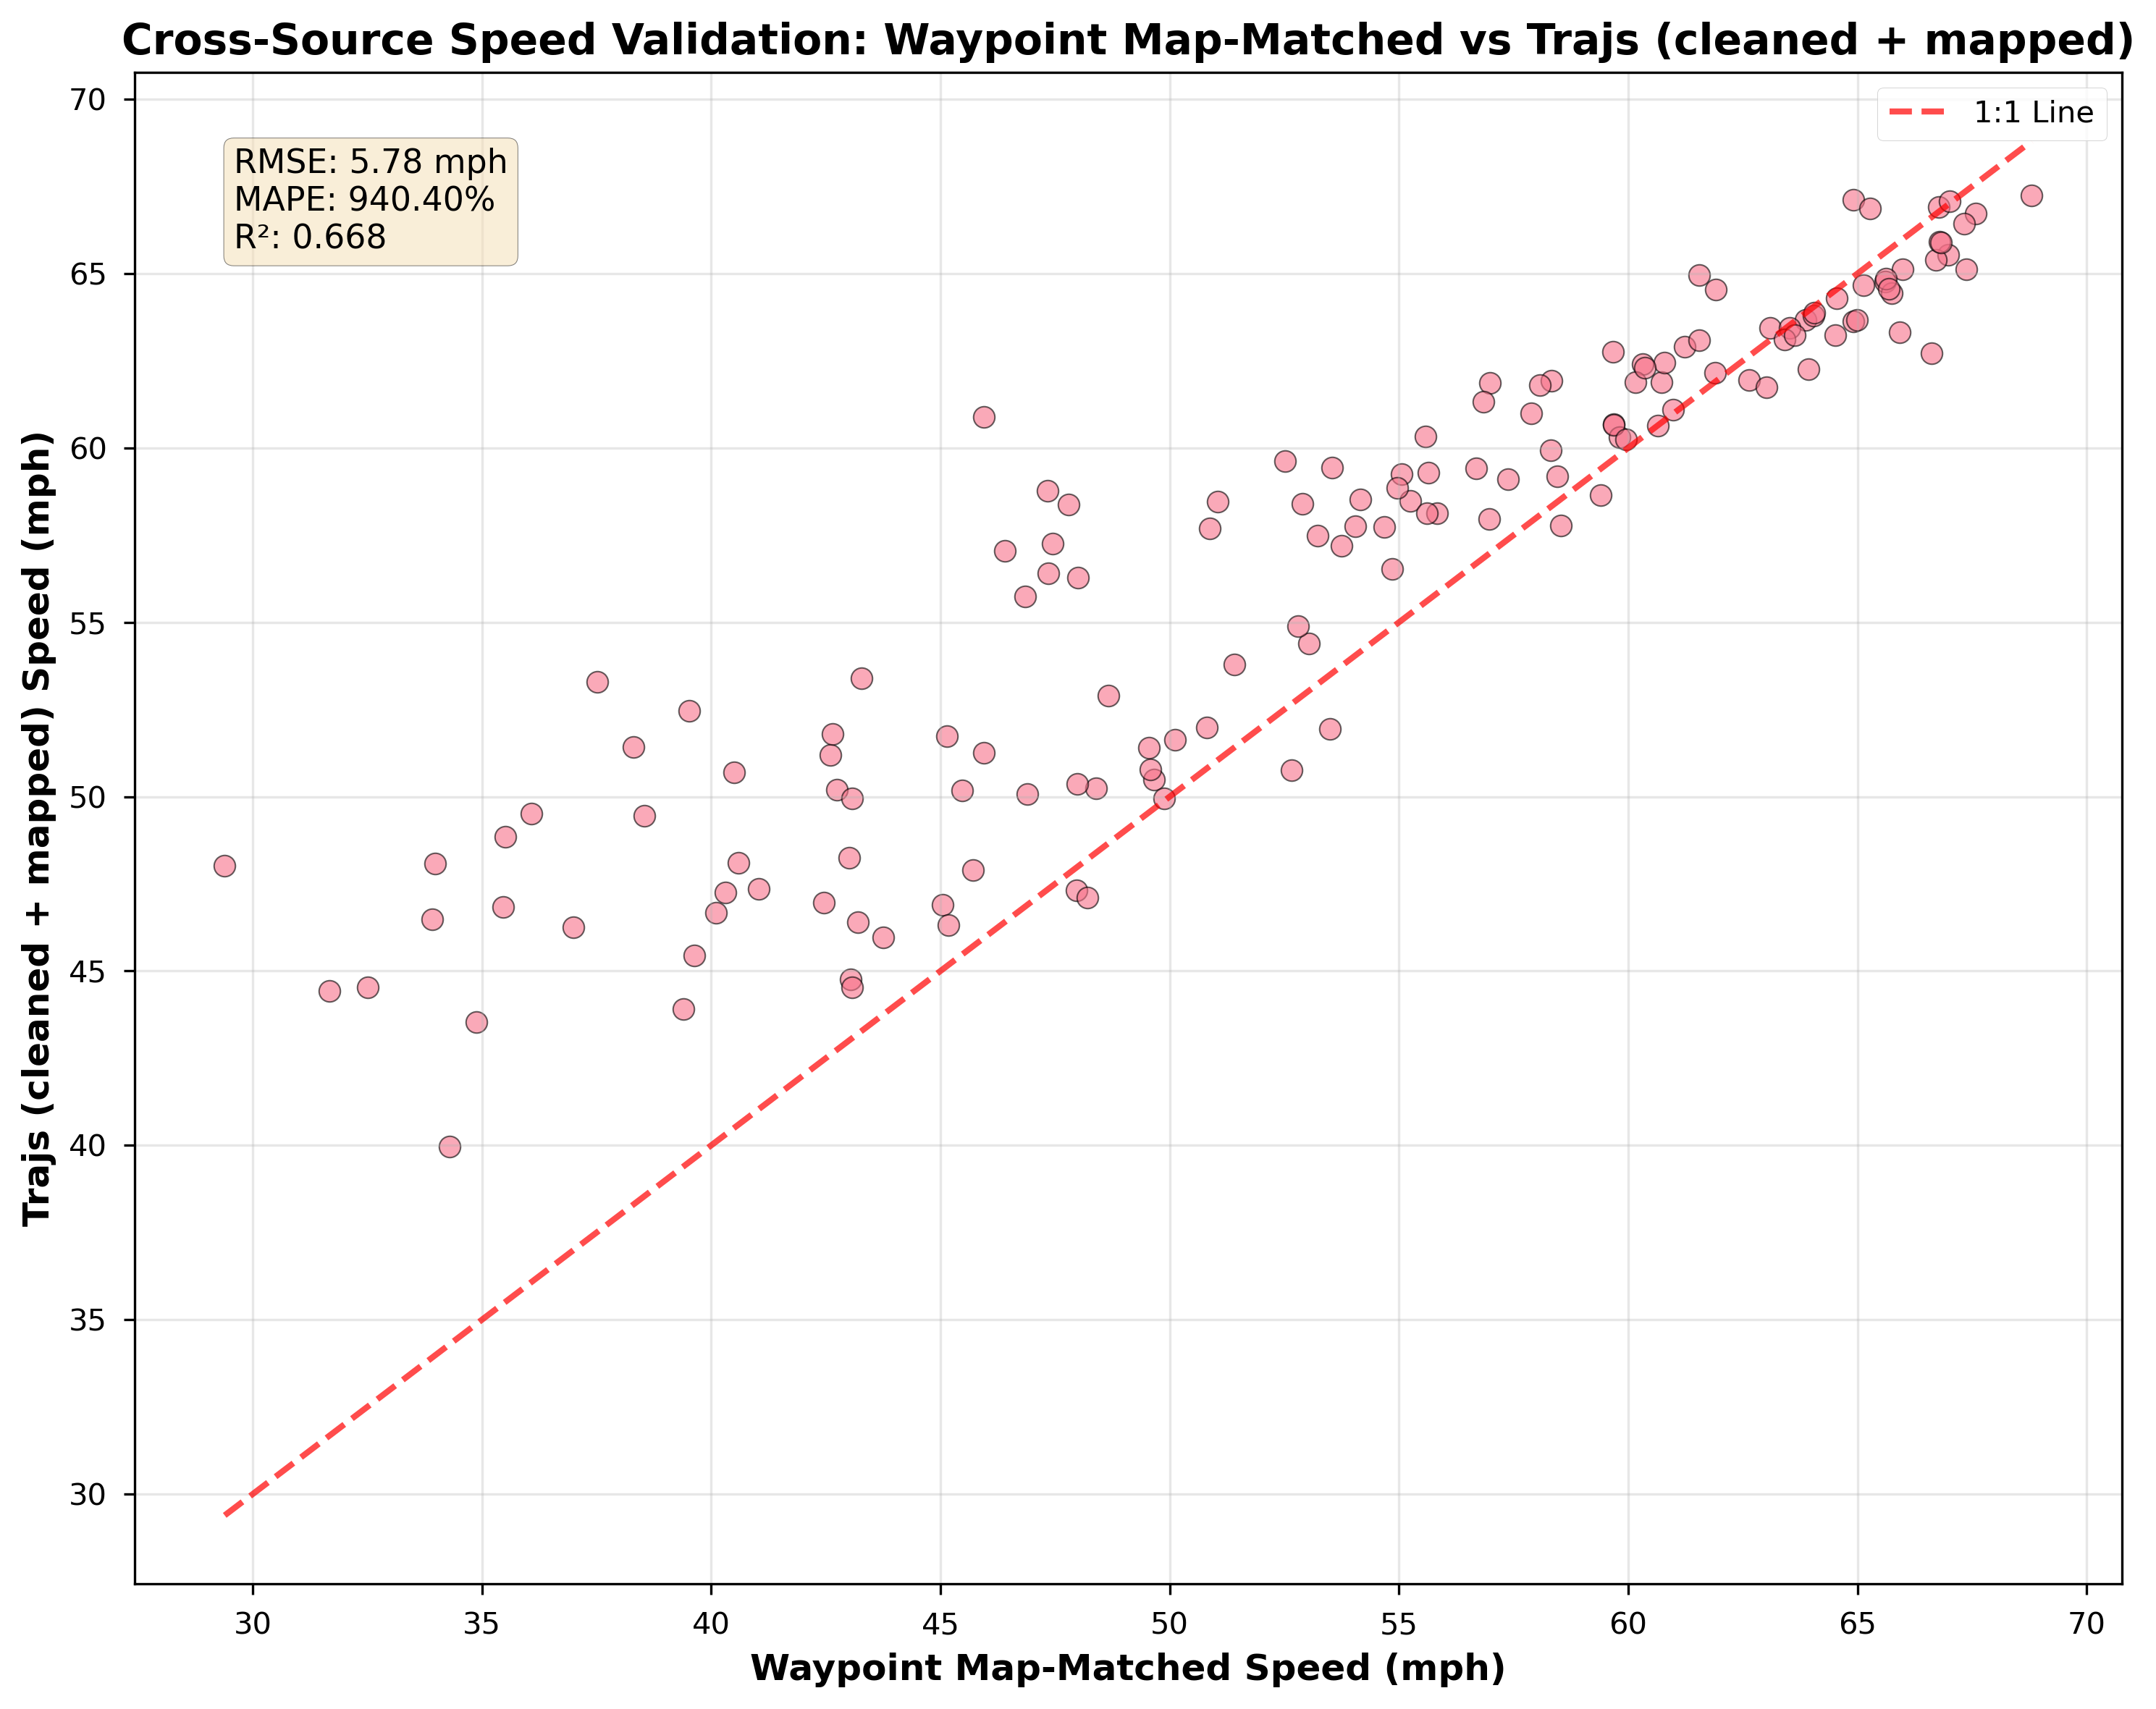

In [110]:
# Create validation scatter plot
if merged_data is not None and len(merged_data) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(merged_data['avg_speed_waypoint'], merged_data['avg_speed_trajs'], 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Add 1:1 line
    min_speed = min(merged_data['avg_speed_waypoint'].min(), merged_data['avg_speed_trajs'].min())
    max_speed = max(merged_data['avg_speed_waypoint'].max(), merged_data['avg_speed_trajs'].max())
    ax.plot([min_speed, max_speed], [min_speed, max_speed], 
            'r--', linewidth=2, label='1:1 Line', alpha=0.7)
    
    # Add metrics text
    metrics_text = f"RMSE: {performance_metrics['waypoint_mapmatched_vs_trajs']['RMSE']:.2f} mph\n"
    metrics_text += f"MAPE: {performance_metrics['waypoint_mapmatched_vs_trajs']['MAPE (%)']:.2f}%\n"
    metrics_text += f"R²: {performance_metrics['waypoint_mapmatched_vs_trajs']['R²']:.3f}"
    
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Waypoint Map-Matched Speed (mph)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Trajs (cleaned + mapped) Speed (mph)', fontweight='bold', fontsize=12)
    ax.set_title('Cross-Source Speed Validation: Waypoint Map-Matched vs Trajs (cleaned + mapped)', fontweight='bold', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'cross_source_validation.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved: cross_source_validation.png")
    plt.show()
else:
    print("⚠️  Skipping visualization - insufficient data for comparison")


---

## 4. Computational Efficiency Analysis {#efficiency}

### Purpose
This section analyzes computational efficiency of the data cleaning pipeline:
- **Runtime Comparisons**: Time per cleaning step
- **Memory Usage**: Peak memory consumption
- **Scalability Analysis**: Performance vs data size

### Metrics Tracked
- Processing time per step
- Memory usage (peak and average)
- Records processed per second
- Scalability trends


In [111]:
# Computational Efficiency Analysis
print("\n" + "="*80)
print("COMPUTATIONAL EFFICIENCY ANALYSIS")
print("="*80)

# Get cleaned data file sizes
print("\n📊 Cleaned Data File Sizes:")
total_size = 0
if WAYPOINT_CLEANED.exists():
    size = WAYPOINT_CLEANED.stat().st_size / (1024**3)  # GB
    total_size += size
    print(f"   Waypoint cleaned: {size:.2f} GB")
if TRAJS_CLEANED.exists():
    size = TRAJS_CLEANED.stat().st_size / (1024**3)  # GB
    total_size += size
    print(f"   Trip path cleaned: {size:.2f} GB")
if MAP_MATCHING_CLEANED.exists():
    size = MAP_MATCHING_CLEANED.stat().st_size / (1024**3)  # GB
    total_size += size
    print(f"   Map matching cleaned: {size:.2f} GB")
print(f"   Total cleaned data: {total_size:.2f} GB")

# Get cleaned data file row counts
efficiency_data = []
if WAYPOINT_CLEANED.exists():
    row_count = sum(1 for _ in open(WAYPOINT_CLEANED)) - 1  # Subtract header
    efficiency_data.append({
        'Data Source': 'waypoint_cleaned',
        'File Size (GB)': WAYPOINT_CLEANED.stat().st_size / (1024**3),
        'Row Count': row_count
    })
if TRAJS_CLEANED.exists():
    row_count = sum(1 for _ in open(TRAJS_CLEANED)) - 1  # Subtract header
    efficiency_data.append({
        'Data Source': 'trajs_cleaned',
        'File Size (GB)': TRAJS_CLEANED.stat().st_size / (1024**3),
        'Row Count': row_count
    })
if MAP_MATCHING_CLEANED.exists():
    row_count = sum(1 for _ in open(MAP_MATCHING_CLEANED)) - 1  # Subtract header
    efficiency_data.append({
        'Data Source': 'map_matching_cleaned',
        'File Size (GB)': MAP_MATCHING_CLEANED.stat().st_size / (1024**3),
        'Row Count': row_count
    })

if efficiency_data:
    efficiency_df = pd.DataFrame(efficiency_data)
    print("\n📊 Cleaned Data Statistics:")
    print(efficiency_df.to_string(index=False))
else:
    print("\n⚠️  No cleaned data files found")
    try:
        row_count = pd.read_sql(f"SELECT COUNT(*) as count FROM {table}", conn)['count'].iloc[0]
        
        # Estimate table size (approximate: assume ~100 bytes per row)
        estimated_size = row_count * 100 / (1024**2)  # MB
        
        efficiency_data.append({
            'Table': table,
            'Row Count': f"{row_count:,}",
            'Estimated Size (MB)': f"{estimated_size:.2f}"
        })
    except Exception as e:
        print(f"⚠️  Error processing table {table}: {e}")

efficiency_df = pd.DataFrame(efficiency_data)
if len(efficiency_df) > 0:
    print("\nTABLE STATISTICS")
    print("="*80)
    print(efficiency_df.to_string(index=False))
    efficiency_df.to_csv(METRICS_PATH / "computational_efficiency.csv", index=False)
    print(f"\n✅ Saved: computational_efficiency.csv")
else:
    print("\n⚠️  No table statistics available")

# Get current memory usage (if psutil is available)
if HAS_PSUTIL:
    try:
        process = psutil.Process(os.getpid())
        memory_mb = process.memory_info().rss / (1024**2)
        print(f"\n💾 Current memory usage: {memory_mb:.2f} MB")
        
        # Get system memory info
        mem = psutil.virtual_memory()
        print(f"💾 System memory: {mem.total / (1024**3):.2f} GB total, {mem.available / (1024**3):.2f} GB available")
    except Exception as e:
        print(f"\n⚠️  Error getting memory info: {e}")
else:
    print("\n💾 Memory tracking not available (psutil not installed)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nAll figures saved to: {FIGURES_PATH}")
print(f"All metrics saved to: {METRICS_PATH}")



COMPUTATIONAL EFFICIENCY ANALYSIS

📊 Cleaned Data File Sizes:
   Waypoint cleaned: 1.10 GB
   Trip path cleaned: 0.11 GB
   Map matching cleaned: 0.99 GB
   Total cleaned data: 2.19 GB

📊 Cleaned Data Statistics:
         Data Source  File Size (GB)  Row Count
    waypoint_cleaned        1.095312   12520301
       trajs_cleaned        0.108580     377563
map_matching_cleaned        0.986872    6360068

TABLE STATISTICS
         Data Source  File Size (GB)  Row Count
    waypoint_cleaned        1.095312   12520301
       trajs_cleaned        0.108580     377563
map_matching_cleaned        0.986872    6360068

✅ Saved: computational_efficiency.csv

💾 Current memory usage: 44.23 MB
💾 System memory: 8.00 GB total, 2.17 GB available

ANALYSIS COMPLETE

All figures saved to: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modelling and Applications/Project/data/output/figures
All metrics saved to: /Users/fawzanalfawzan/Documents/PhD/ASU/Cources/Traffic Simulation Modellin